# Space GPU Datacenter Feasibility Notebook (LLM Inference)

This notebook is a readable, first-pass model for one question:

**Could a space-based GPU fleet plausibly deliver useful LLM inference capacity?**

It is intentionally simplified for a general technical audience. The goal is not mission-grade precision, but to show the first-order physics and cost tradeoffs clearly.

We focus on three coupled drivers:

1. **Thermal rejection**: every watt of electrical load becomes heat that must be radiated away.
2. **Sunlight availability**: eclipse time drives array oversizing and battery requirements.
3. **Mass and cost scaling**: thermal + power hardware mass propagates into launch cost.

Throughout the notebook, assumptions are explicit and easy to edit.

## Baseline assumptions (editable)

This model starts from an example "cluster satellite" built around a single **NVIDIA GB200 NVL72** rack equivalent — 72 Blackwell B200 GPUs — and tracks how design choices propagate.

### GPU and compute-module reference hardware

| Parameter | Value | Source |
|---|---|---|
| GPU | NVIDIA B200 (Blackwell, TSMC 4 nm, dual-die) | [NVIDIA B200 product page](https://www.nvidia.com/en-us/data-center/gb200-nvl2/) |
| TDP per GPU | 1,000 W | [NVIDIA DGX B200 User Guide](https://docs.nvidia.com/dgx/dgxb200-user-guide/introduction-to-dgxb200.html) |
| HBM3e per GPU | 192 GB @ 8 TB/s bandwidth | [NVIDIA DGX B200 Datasheet](https://resources.nvidia.com/en-us-dgx-platform/dgx-b200-datasheet) |
| FP4 inference per GPU | ~18 PFLOPS | [NVIDIA DGX B200 Datasheet](https://resources.nvidia.com/en-us-dgx-platform/dgx-b200-datasheet) (144 PFLOPS / 8 GPUs for DGX B200) |
| NVL72 rack power | 120 kW (72 GPUs + 36 Grace CPUs + NVLink switches) | [NVIDIA DGX GB200 User Guide — Hardware](https://docs.nvidia.com/dgx/dgxgb200-user-guide/hardware.html) |
| NVL72 ground mass | 3,000 kg (with liquid cooling, rack frame, AC PSUs) | [Introl GB200 NVL72 Deployment Guide](https://introl.com/blog/gb200-nvl72-deployment-72-gpu-liquid-cooled) |
| DGX B200 (8-GPU server) mass | 142.4 kg | [NVIDIA DGX B200 User Guide](https://docs.nvidia.com/dgx/dgxb200-user-guide/introduction-to-dgxb200.html) |

### Satellite-level assumptions

- **Compute load**: 120 kW nameplate (full NVL72 system power) plus 10 % spacecraft overhead.
- **Compute hardware mass**: ~750 kg (space-optimized estimate — see derivation in model knobs cell).
- **Radiators**: emissivity 0.9, areal density 2 kg/m², baseline radiator temperature from GPU junction temp minus thermal drop.
- **Power system**: solar arrays at 200 W/kg.
- **Bus/structure**: modeled as 25 % of total mass.

The compute power and mass values are grounded in published NVIDIA specs; other parameters remain scenario assumptions for rapid iteration.

In Section 1, we briefly compare two power-system concepts — **sunlight-only** (compute only when sunlit) vs **24/7 with batteries** — and show why sunlight-only is the clear winner for a large constellation. The rest of the notebook adopts sunlight-only throughout.

In [17]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style for blog-friendly readability
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [18]:
# Physical constants (SI)
SIGMA = 5.670374419e-8   # Stefan–Boltzmann constant [W / m^2 / K^4]
SOLAR_CONSTANT = 1361.0  # Solar irradiance at 1 AU [W/m^2] (assumption)

R_EARTH = 6_371_000.0    # Earth mean radius [m]
MU_EARTH = 3.986004418e14 # Earth's gravitational parameter [m^3/s^2]
G0 = 9.80665             # Standard gravity [m/s^2]


## Model knobs (edit here)

Keep everything in one place so the notebook stays easy to read.


In [19]:
# ==== Compute / load (NVIDIA GB200 NVL72 reference) ====
#
# Hardware basis: one NVIDIA GB200 NVL72 rack (72 × Blackwell B200 GPUs).
#
# Per-GPU specs (B200 SXM):
#   TDP:               1,000 W
#   Memory:            192 GB HBM3e, 8 TB/s bandwidth
#   FP4 inference:     ~18 PFLOPS   (DGX B200: 144 PFLOPS / 8 GPUs)
#   FP8 training:      ~9 PFLOPS    (DGX B200: 72 PFLOPS / 8 GPUs)
#
# System-level (GB200 NVL72):
#   Config:  18 compute trays (4 B200 GPUs + 2 Grace CPUs each) + 9 NVLink switch trays
#   Rack power:        120 kW  (GPUs + Grace CPUs + NVLink switches + networking)
#   GPU-only power:    72 kW   (72 × 1,000 W TDP)
#   Ground mass:       3,000 kg (includes liquid cooling, rack frame, AC power shelves)
#
# Space-optimized mass estimate (750 kg):
#   The 3,000 kg ground mass includes heavy items absent in a spacecraft:
#   liquid-cooling manifolds and plumbing, 42U rack frame, AC→DC power shelves,
#   bulk NVMe storage, and fan/airflow ducting.
#   Stripping those and retaining GPU boards, Grace CPUs, NVLink switches,
#   PCBs, and minimal structural housing yields ~25% of ground mass.
#   Cross-check: DGX B200 (8-GPU air-cooled server) weighs 142.4 kg;
#   removing PSUs, SSDs, fans, and heavy chassis ≈ 60–70 kg per 8 GPUs,
#   scaled to 72 GPUs ≈ 540–630 kg + NVLink switch trays ≈ 700–800 kg.
#
# Sources:
#   NVIDIA DGX GB200 User Guide — Hardware
#     https://docs.nvidia.com/dgx/dgxgb200-user-guide/hardware.html
#   NVIDIA DGX B200 User Guide (weight, power, per-GPU TDP)
#     https://docs.nvidia.com/dgx/dgxb200-user-guide/introduction-to-dgxb200.html
#   NVIDIA DGX B200 Datasheet (PFLOPS figures)
#     https://resources.nvidia.com/en-us-dgx-platform/dgx-b200-datasheet
#   NVIDIA Blackwell inference benchmarks (DeepSeek-R1, Llama 4)
#     https://developer.nvidia.com/blog/nvidia-blackwell-delivers-world-record-deepseek-r1-inference-performance/
#   Introl GB200 NVL72 deployment guide (rack mass, cooling)
#     https://introl.com/blog/gb200-nvl72-deployment-72-gpu-liquid-cooled
#
N_GPUS = 72                        # GPUs per compute module (GB200 NVL72 configuration)
GPU_TDP_W = 1_000.0                # single B200 GPU TDP [W]
P_COMPUTE_KW = 120.0               # compute module electrical power [kW]
                                    # (full NVL72 rack: GPUs + Grace CPUs + NVLink switches)
OVERHEAD_FRAC = 0.10               # additional spacecraft-level overhead
                                    # (power conditioning, attitude control, comms — beyond compute)
M_COMPUTE_KG = 750.0               # space-optimized compute module mass [kg]
                                    # (see derivation above; ground NVL72 is 3,000 kg)
COMPUTE_COST_PER_KW = 16_000.0      # $ per nameplate compute kW (placeholder; coupled cost model)

# ==== Thermal ====
T_GPU_C = 90.0                     # GPU junction / target hot-side temperature [°C]
DELTA_T_TO_RADIATOR_C = 30.0       # thermal drop to radiator surface [°C]
EPSILON = 0.90                     # radiator IR emissivity
ALPHA_SOLAR = 0.20                 # radiator solar absorptivity (OSR-like surfaces are low-alpha)
ALPHA_IR = 0.90                    # absorptivity in thermal IR (Kirchhoff approx: ~epsilon)
T_SINK_K = 3.0                     # deep-space sink [K]
K_EFFECTIVE = 0.90                 # de-rate for non-ideal view/packaging (1.0 = ideal)

# Earth-space thermal environment references:
# - Solar irradiance near 1 AU: 1361 W/m² (TSIS/SORCE era)
# - Earth IR design value: 234 ± 7 W/m² (NASA ARC-STD-8070.1)
# - Earth Bond albedo ~0.29-0.30 (NASA NSSDC / CERES context)
EARTH_IR_FLUX_W_PER_M2 = 234.0
EARTH_BOND_ALBEDO = 0.294

# Radiator pointing / exposure model (tunable)
# We compute geometric max Earth view factor as (R_earth / r_orbit)^2 and then scale it
# by a design factor to represent anti-Earth pointing + shielding.
EARTH_VIEW_FRACTION_OF_MAX = 0.10
RADIATOR_SOLAR_VIEW_FACTOR = 0.02   # residual direct-solar exposure fraction when sunlit
ALBEDO_GEOMETRY_FACTOR = 0.50       # Lambertian/reflection geometry de-rate

RADIATOR_AREAL_DENSITY = 2.0        # kg/m^2 (assumption)
RADIATOR_COST_PER_M2 = 2_000.0      # $/m^2 (placeholder)

# ==== Solar arrays ====
ARRAY_SPECIFIC_POWER_W_PER_KG = 200.0   # W/kg (assumption)
ARRAY_POWER_DENSITY_W_PER_M2 = 400.0    # W/m^2 at bus (assumption; bundles efficiency+derates)
ARRAY_COST_PER_W = 50.0                 # $/W (placeholder)

# ==== Batteries (optional for 24/7) ====
BATTERY_SPECIFIC_ENERGY_WH_PER_KG = 200.0   # Wh/kg (assumption)
BATTERY_ROUND_TRIP_EFF = 0.9
BATTERY_DOD = 0.8
BATTERY_COST_PER_KWH = 200.0               # $/kWh (placeholder)

# ==== Satellite bus / chassis ====
BUS_MASS_FRACTION_OF_TOTAL = 0.25      # 25% of total mass is "bus/chassis"
BUS_COST_FIXED = 500_000.0             # $ per satellite (placeholder)

# ==== Orbit / launch cost ====
#
# Two-tier launch cost model:
#   1. Pay COST_TO_BASELINE_PER_KG to deliver mass to ALT_BASELINE_KM (launch vehicle price / capacity).
#   2. For higher orbits, the satellite carries a kick-stage for a Hohmann transfer.
#      The Tsiolkovsky rocket equation gives the propellant penalty, and
#      PROPULSION_STRUCT_FRAC accounts for kick-stage dry mass (tanks, engine).
#
# Reference launch costs to ~550 km LEO ($/kg, as of 2025-2026):
#   Vehicle                     $/kg         Basis
#   ────────────────────────── ──────────── ──────────────────────────────────────
#   Falcon 9 (reusable)        ~$4,000      ~$67 M list / ~16,000 kg to 550 km
#   Falcon Heavy (reusable)    ~$1,500      ~$97 M list / ~63,800 kg LEO
#   Starship (early ops)       ~$500–1,500  ~$100–150 M / ~100,000 kg (projected)
#   Starship (mature reuse)    ~$50–200     $10–30 M / 100,000 kg (SpaceX target)
#
# Sources:
#   SpaceX Falcon 9 User's Guide (May 2025 rev): payload performance tables
#     https://www.spacex.com/media/falcon-users-guide-2025-05-09.pdf
#   CSIS Aerospace Security "Space Launch to LEO: How Much Does It Cost?"
#     https://aerospace.csis.org/data/space-launch-to-low-earth-orbit-how-much-does-it-cost/
#   NextBigFuture Falcon 9 cost analysis (Feb 2026)
#     https://www.nextbigfuture.com/2026/02/
#
ALT_BASELINE_KM = 550.0                # baseline deployment orbit [km]
BETA_DEG = 0.0                         # beta angle [deg]; 0 = worst-case eclipse season

COST_TO_BASELINE_PER_KG = 2_500.0      # $/kg to baseline LEO orbit
                                        # Mid-range: between Falcon 9 (~$4,000/kg) and
                                        # Falcon Heavy (~$1,500/kg).  Adjust per vehicle scenario.

ISP_TRANSFER_S = 320.0                 # In-space kick-stage Isp [s]
                                        # ~320 s for storable bipropellant (MMH/NTO).
                                        # Use ~1,500–3,000 s for electric propulsion (slower transfer).

PROPULSION_STRUCT_FRAC = 0.12          # Kick-stage dry-mass fraction of propellant mass
                                        # (tanks + engine ≈ 5–15 % of propellant; 0.12 is mid-range).
                                        # Set to 0.0 to recover the ideal rocket-equation limit.

# ==== Constellation sizing (optional) ====
TARGET_TOTAL_COMPUTE_MW = 10.0         # total desired compute power in orbit [MW] (inference fleet size)

# Coverage-oriented sunlight mix across planes (simple, blog-friendly approximation).
# Interpretation: fraction of satellites/planes operating at each representative beta.
# Rationale: a large internet-serving constellation needs many local times and RAANs,
# so not every plane can stay near dawn-dusk high-beta conditions.
CONSTELLATION_BETA_MIX = [
    (0.0, 0.30),
    (30.0, 0.45),
    (60.0, 0.20),
    (90.0, 0.05),
]


## Core equations

### 1) Electrical load (treated as heat to reject)

In a terrestrial data center, waste heat is someone else's problem — a building's chillers and cooling towers carry it away. In space, every watt the satellite consumes must be radiated into the vacuum. That makes the **total electrical load** the single most important input to thermal sizing.

For a rack of inference GPUs the load breaks down into two pieces:

- **GPU silicon.** Each NVIDIA B200 GPU draws up to 1,000 W (its rated TDP). With 72 GPUs that gives $P_{GPU} = N_{GPU} \times \text{TDP} = 72$ kW.
- **Supporting silicon.** The GPUs don't work alone — Grace CPUs, NVLink switches, and high-speed networking add roughly another 48 kW, bringing the published rack power to $P_{compute} = 120$ kW. A different GPU (or fewer of them) would change both terms.

On top of the compute module itself, the spacecraft needs power conditioning, attitude control, and communications hardware. We capture that with a flat overhead fraction $f_{overhead}$:

$P_{load} \approx P_{compute}\,(1 + f_{overhead})$

Because inference ASICs convert virtually all input power to heat (there is no useful mechanical work), $P_{load}$ is also the **heat rejection requirement** that drives radiator area, which is the subject of the next section.

### 2) Radiator sizing with environmental backload
Ideal radiative rejection is:

$q_{emit} = \epsilon\,\sigma\,k_{eff}\,(T_{rad}^4 - T_{sink}^4)$

But radiators absorb environmental flux (Earth IR, albedo, and residual direct solar), so net rejection is:

$q_{net} = q_{emit} - q_{backload}$

Required radiator area is:

$A_{rad} = Q_{load}/q_{net}$

### 3) Sunlight fraction vs altitude and beta angle
A simple cylindrical-shadow orbit model gives the sunlight fraction $f_{sun}$.

- Lower $f_{sun}$ means longer eclipses and more compute downtime per satellite.
- A constellation with diverse orbital planes provides fleet-level averaging.

In [20]:
P_GPU_ONLY_KW = N_GPUS * GPU_TDP_W / 1_000.0
P_SUPPORT_KW = P_COMPUTE_KW - P_GPU_ONLY_KW
P_LOAD_TOTAL_KW = P_COMPUTE_KW * (1 + OVERHEAD_FRAC)

print(f"GPU power (72 × {GPU_TDP_W:.0f} W):  {P_GPU_ONLY_KW:6.0f} kW  ({P_GPU_ONLY_KW/P_LOAD_TOTAL_KW:.0%} of heat load)")
print(f"CPUs / NVLink / networking:   {P_SUPPORT_KW:6.0f} kW  ({P_SUPPORT_KW/P_LOAD_TOTAL_KW:.0%} of heat load)")
print(f"Spacecraft overhead ({OVERHEAD_FRAC:.0%}):    {P_COMPUTE_KW * OVERHEAD_FRAC:6.0f} kW  ({P_COMPUTE_KW * OVERHEAD_FRAC/P_LOAD_TOTAL_KW:.0%} of heat load)")
print(f"{'─'*54}")
print(f"Total heat to reject:         {P_LOAD_TOTAL_KW:6.0f} kW")

GPU power (72 × 1000 W):      72 kW  (55% of heat load)
CPUs / NVLink / networking:       48 kW  (36% of heat load)
Spacecraft overhead (10%):        12 kW  (9% of heat load)
──────────────────────────────────────────────────────
Total heat to reject:            132 kW


### Thermal environment source notes

This notebook uses the following external reference values for first-order thermal backload:
- Solar irradiance near 1 AU (TSI): ~1361 W/m² from Kopp & Lean (2011), *A New, Lower Value of Total Solar Irradiance* (GRL): https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2010GL045777
- Earth IR design value for Earth-orbiting missions: 234 ± 7 W/m² (NASA ARC-STD-8070.1): https://ntrs.nasa.gov/citations/20160009122
- Earth Bond albedo baseline: 0.294 (NASA NSSDC Earth Fact Sheet): https://nssdc.gsfc.nasa.gov/planetary/factsheet/earthfact.html


### Launch cost model

Launch cost is often the dominant "space premium" in this notebook. Rather than treating altitude as a simple linear `$/km` surcharge, we model it in three steps:

1. **Altitude sets the transfer energy.**
   To raise a satellite from the baseline deployment orbit (`ALT_BASELINE_KM = 550 km`) to a higher circular orbit, we compute the required Hohmann-transfer $\Delta v$.

2. **Transfer energy sets the equivalent launched mass.**
   Any way of supplying that $\Delta v$ — onboard propellant, a space tug, or additional performance from the launch vehicle's upper stage — ultimately means that **more mass-equivalent must be delivered to the baseline orbit** in order to place `1 kg` at the final altitude.

3. **Equivalent launched mass sets the dollar premium.**
   We convert that mass penalty into dollars by multiplying it by the baseline launch price to `550 km`.

This makes the model intentionally **vehicle-agnostic**. The notebook does not try to decide whether the orbit raise is performed by a kick stage, a tug, or the launch vehicle itself. Instead, it asks a simpler economic question:

> How much extra mass-to-550-km capability is required to deliver `1 kg` to the final orbit?

The Hohmann transfer gives the required $\Delta v(h)$ from the baseline orbit $h_0$ to target altitude $h$:

$$
\Delta v(h) = \Delta v_{\text{Hohmann}}(h_0 \rightarrow h)
$$

We then convert that to an ideal rocket mass ratio:

$$
R(h) = \exp\!\left(\frac{\Delta v(h)}{g_0 I_{sp}}\right)
$$

If the transfer system has dry mass as well as propellant, with structural fraction

$$
f = \frac{m_{\text{dry, transfer}}}{m_{\text{propellant}}}
$$

then the effective mass multiplier becomes

$$
M(h) = \frac{R(h)}{1 - f\,[R(h)-1]}
$$

This multiplier answers the question: **how many kilograms must be delivered to `550 km` in order to deliver `1 kg` to the final orbit?**

The effective delivered launch cost at altitude $h$ is therefore

$$
c_{\text{delivered}}(h) = c_{550} \, M(h)
$$

The **incremental altitude premium** is then

$$
\Delta c_{\text{alt}}(h) = c_{550} \, [M(h)-1]
$$

and for a satellite of mass $m_{\text{sat}}$ at the target orbit, the total altitude-related launch premium is

$$
\Delta C_{\text{sat}}(h) = m_{\text{sat}} \, c_{550} \, [M(h)-1]
$$

### Equation to use in the blog

For the blog, the clearest headline equation is

$$
\boxed{\Delta C_{\text{sat}}(h) = m_{\text{sat}} \, c_{550} \, [M(h)-1]}
$$

This is the most directly interpretable form: altitude costs money because it forces you to buy more equivalent mass to the baseline orbit.

### Why `$/km` is only a reporting shortcut

A `$/km` number can be useful as a summary heuristic, but it is **not** the underlying model. The relationship is nonlinear: the implied premium per additional kilometer changes with altitude because orbital energy and transfer mass ratio are nonlinear.

If desired, we can still report an average implied altitude price as

$$
\bar c_{km}(h) = \frac{\Delta c_{\text{alt}}(h)}{h-h_0}
$$

but this should be interpreted only as a summary metric over that altitude range, not as a constant rule.

**What the launch cost covers.** The total satellite dry mass — compute modules, radiators, solar arrays, batteries, and bus/chassis — is multiplied by the effective $/kg delivered. This means heavier radiators and larger solar arrays directly increase launch cost, making mass a first-order cost driver throughout the model.

**Limitations.** This is a first-order economic model for sensitivity analysis, not a procurement tool. It does not capture plane changes, finite-burn losses, transfer time, tug reuse, fairing volume constraints, or launcher-specific staging and pricing.

In [21]:
def total_load_w(p_compute_kw: float, overhead_frac: float) -> float:
    """Total electrical load in watts (also treated as heat to reject)."""
    return 1_000.0 * p_compute_kw * (1.0 + overhead_frac)

def radiator_temp_c(t_gpu_c: float, delta_t_c: float) -> float:
    """Radiator surface temperature based on GPU hot-side temperature minus a thermal drop."""
    return t_gpu_c - delta_t_c

def orbital_period_s(alt_km: float) -> float:
    """Orbital period for a circular orbit."""
    r = R_EARTH + 1_000.0 * alt_km
    return 2*np.pi*np.sqrt(r**3 / MU_EARTH)

def sunlight_fraction(alt_km: float, beta_deg: float=0.0) -> float:
    """
    Fraction of an orbit in sunlight using a simple cylindrical Earth shadow model.

    beta_deg here is the angle between the Sun vector and the orbit plane:
      - beta = 0°  -> worst-case eclipses (Sun in the orbit plane)
      - beta -> 90° -> continuous sun possible

    If |beta| is large enough, there is no eclipse.
    """
    r = R_EARTH + 1_000.0 * alt_km
    beta = np.deg2rad(beta_deg)
    ratio = R_EARTH / r

    if abs(np.sin(beta)) >= ratio:
        return 1.0

    X = (ratio**2 - np.sin(beta)**2) / (np.cos(beta)**2)
    X = np.clip(X, 0.0, 1.0)
    theta_e = np.arcsin(np.sqrt(X))
    return float(1.0 - theta_e/np.pi)

def normalize_beta_mix(beta_mix: list) -> list:
    """Normalize [(beta_deg, weight), ...] so weights sum to 1."""
    arr = np.array(beta_mix, dtype=float)
    if arr.ndim != 2 or arr.shape[1] != 2:
        raise ValueError("beta_mix must be list of (beta_deg, weight)")
    total = np.sum(arr[:, 1])
    if total <= 0:
        raise ValueError("beta_mix must have positive total weight")
    arr[:, 1] = arr[:, 1] / total
    return [(float(b), float(w)) for b, w in arr]

def constellation_sunlight_metrics(alt_km: float, beta_mix: list) -> dict:
    """
    Weighted sunlight metrics for a multi-plane constellation.

    Uses per-plane sunlight_fraction(alt, beta), then computes weighted averages:
      - mean sunlight fraction
      - mean eclipse minutes per orbit
      - mean 24/7 array oversize factor E[1/f_sun]
    """
    mix = normalize_beta_mix(beta_mix)
    t_orbit_s = orbital_period_s(alt_km)

    betas = np.array([b for b, _ in mix], dtype=float)
    weights = np.array([w for _, w in mix], dtype=float)
    f_vals = np.array([sunlight_fraction(alt_km, b) for b in betas], dtype=float)

    f_mean = float(np.sum(weights * f_vals))
    eclipse_min_mean = float(np.sum(weights * (1.0 - f_vals) * t_orbit_s / 60.0))
    array_oversize_247_mean = float(np.sum(weights * (1.0 / np.maximum(f_vals, 1e-6))))

    return {
        "sunlight_fraction_weighted": f_mean,
        "eclipse_min_weighted": eclipse_min_mean,
        "array_oversize_247_weighted": array_oversize_247_mean,
    }

def earth_view_factor_max(alt_km: float) -> float:
    """
    Maximum geometric view factor from a flat radiator to Earth disk when nadir-facing.
    For a differential surface, F_max = sin^2(alpha) with sin(alpha)=R_earth/r.
    """
    r = R_EARTH + 1_000.0 * alt_km
    return float((R_EARTH / r)**2)

def radiator_backload_flux_w_m2(
    alt_km: float,
    beta_deg: float,
    alpha_solar: float,
    alpha_ir: float,
    earth_ir_flux_w_m2: float,
    earth_bond_albedo: float,
    earth_view_fraction_of_max: float,
    radiator_solar_view_factor: float,
    albedo_geometry_factor: float,
) -> dict:
    """
    First-order absorbed environmental heat flux on radiator [W/m^2].

    Components:
      - Earth IR (all orbit, scaled by Earth view)
      - Albedo shortwave (sunlit fraction only)
      - Residual direct solar (sunlit fraction only)
    """
    f_sun = sunlight_fraction(alt_km, beta_deg)

    f_earth = earth_view_factor_max(alt_km) * earth_view_fraction_of_max
    f_earth = float(np.clip(f_earth, 0.0, 1.0))

    q_ir = alpha_ir * earth_ir_flux_w_m2 * f_earth
    q_albedo = alpha_solar * SOLAR_CONSTANT * earth_bond_albedo * f_earth * albedo_geometry_factor * f_sun
    q_solar = alpha_solar * SOLAR_CONSTANT * radiator_solar_view_factor * f_sun

    q_total = q_ir + q_albedo + q_solar
    return {
        "q_backload_total_w_m2": float(q_total),
        "q_backload_earth_ir_w_m2": float(q_ir),
        "q_backload_albedo_w_m2": float(q_albedo),
        "q_backload_solar_w_m2": float(q_solar),
        "earth_view_factor_effective": f_earth,
        "sunlight_fraction": float(f_sun),
    }

def radiator_area_m2_with_backload(
    q_internal_w: float,
    t_rad_c: float,
    alt_km: float,
    beta_deg: float,
    epsilon: float,
    t_sink_k: float,
    k_eff: float,
    alpha_solar: float,
    alpha_ir: float,
    earth_ir_flux_w_m2: float,
    earth_bond_albedo: float,
    earth_view_fraction_of_max: float,
    radiator_solar_view_factor: float,
    albedo_geometry_factor: float,
) -> tuple:
    """
    Required radiator area using net rejectable flux = emitted - absorbed backload.
    Returns (area_m2, diagnostics_dict).
    """
    t_rad_k = t_rad_c + 273.15
    q_emit = epsilon * SIGMA * k_eff * (t_rad_k**4 - t_sink_k**4)

    back = radiator_backload_flux_w_m2(
        alt_km=alt_km,
        beta_deg=beta_deg,
        alpha_solar=alpha_solar,
        alpha_ir=alpha_ir,
        earth_ir_flux_w_m2=earth_ir_flux_w_m2,
        earth_bond_albedo=earth_bond_albedo,
        earth_view_fraction_of_max=earth_view_fraction_of_max,
        radiator_solar_view_factor=radiator_solar_view_factor,
        albedo_geometry_factor=albedo_geometry_factor,
    )
    q_net = q_emit - back["q_backload_total_w_m2"]

    if q_net <= 0:
        return np.inf, {
            **back,
            "q_emit_w_m2": float(q_emit),
            "q_net_w_m2": float(q_net),
        }

    area = q_internal_w / q_net
    return float(area), {
        **back,
        "q_emit_w_m2": float(q_emit),
        "q_net_w_m2": float(q_net),
    }

def hohmann_delta_v_m_s(alt1_km: float, alt2_km: float) -> float:
    """Two-impulse Hohmann transfer delta-v between circular orbits at alt1 and alt2."""
    r1 = R_EARTH + 1_000.0 * alt1_km
    r2 = R_EARTH + 1_000.0 * alt2_km
    v1 = np.sqrt(MU_EARTH / r1)
    v2 = np.sqrt(MU_EARTH / r2)
    a_t = 0.5 * (r1 + r2)
    v_t1 = np.sqrt(MU_EARTH * (2/r1 - 1/a_t))
    v_t2 = np.sqrt(MU_EARTH * (2/r2 - 1/a_t))
    dv1 = abs(v_t1 - v1)
    dv2 = abs(v2 - v_t2)
    return float(dv1 + dv2)

def effective_cost_per_kg_to_altitude(
    alt_km: float,
    alt_baseline_km: float,
    cost_to_baseline_per_kg: float,
    isp_s: float,
    propulsion_struct_frac: float = 0.0,
) -> float:
    """
    Two-tier launch cost model.

    1. Pay *cost_to_baseline_per_kg* to reach the baseline LEO orbit.
    2. For higher orbits, a Hohmann transfer adds delta-v, and the
       Tsiolkovsky equation gives the propellant mass ratio R = exp(Δv/(g₀·Isp)).
       The kick-stage structural fraction *propulsion_struct_frac* (dry mass as a
       fraction of propellant mass) increases the total mass that must be
       launched to the baseline orbit:

           mass_multiplier = R / (1 − f_struct × (R − 1))

       When f_struct = 0, this reduces to the ideal rocket equation (R alone).

    Returns effective $/kg *delivered* to the target altitude.
    """
    if alt_km <= alt_baseline_km:
        return cost_to_baseline_per_kg

    dv = hohmann_delta_v_m_s(alt_baseline_km, alt_km)
    R = np.exp(dv / (G0 * isp_s))

    if propulsion_struct_frac > 0:
        denom = 1.0 - propulsion_struct_frac * (R - 1.0)
        if denom <= 0:
            return np.inf
        mass_multiplier = R / denom
    else:
        mass_multiplier = R

    return float(cost_to_baseline_per_kg * mass_multiplier)


## 1) Baseline single-satellite sizing — and why we choose sunlight-only

Before diving into detailed thermal and orbital analysis, we answer a key design question: **should each satellite carry batteries for 24/7 operation, or simply compute only when sunlit?**

The table below compares both modes at a baseline 550 km, worst-case eclipse orbit. After seeing the mass penalty, we commit to sunlight-only for the rest of the notebook.


In [22]:
# Baseline load and radiator
P_COMPUTE_W = 1_000.0 * P_COMPUTE_KW
P_LOAD_W = total_load_w(P_COMPUTE_KW, OVERHEAD_FRAC)
T_RAD_C = radiator_temp_c(T_GPU_C, DELTA_T_TO_RADIATOR_C)

A_RAD_M2, RAD_DIAG_BASE = radiator_area_m2_with_backload(
    q_internal_w=P_LOAD_W,
    t_rad_c=T_RAD_C,
    alt_km=ALT_BASELINE_KM,
    beta_deg=BETA_DEG,
    epsilon=EPSILON,
    t_sink_k=T_SINK_K,
    k_eff=K_EFFECTIVE,
    alpha_solar=ALPHA_SOLAR,
    alpha_ir=ALPHA_IR,
    earth_ir_flux_w_m2=EARTH_IR_FLUX_W_PER_M2,
    earth_bond_albedo=EARTH_BOND_ALBEDO,
    earth_view_fraction_of_max=EARTH_VIEW_FRACTION_OF_MAX,
    radiator_solar_view_factor=RADIATOR_SOLAR_VIEW_FACTOR,
    albedo_geometry_factor=ALBEDO_GEOMETRY_FACTOR,
)
M_RAD_KG = A_RAD_M2 * RADIATOR_AREAL_DENSITY

# Solar arrays (peak power to run when sunlit)
P_ARRAY_PEAK_W_SUNONLY = P_LOAD_W  # no charging; compute runs only when sunlit
M_ARRAY_KG_SUNONLY = P_ARRAY_PEAK_W_SUNONLY / ARRAY_SPECIFIC_POWER_W_PER_KG
A_ARRAY_M2_SUNONLY = P_ARRAY_PEAK_W_SUNONLY / ARRAY_POWER_DENSITY_W_PER_M2

# Sunlight fraction at baseline orbit
F_SUN_BASE = sunlight_fraction(ALT_BASELINE_KM, BETA_DEG)
T_ORBIT_S_BASE = orbital_period_s(ALT_BASELINE_KM)
T_ECLIPSE_S_BASE = (1 - F_SUN_BASE) * T_ORBIT_S_BASE

# Arrays + batteries for 24/7 operation at baseline orbit
P_ARRAY_PEAK_W_247 = P_LOAD_W / max(F_SUN_BASE, 1e-6)  # energy balance (simplified)
M_ARRAY_KG_247 = P_ARRAY_PEAK_W_247 / ARRAY_SPECIFIC_POWER_W_PER_KG
A_ARRAY_M2_247 = P_ARRAY_PEAK_W_247 / ARRAY_POWER_DENSITY_W_PER_M2

E_BATT_WH = (P_LOAD_W/1000) * (T_ECLIPSE_S_BASE/3600) / (BATTERY_ROUND_TRIP_EFF * BATTERY_DOD) * 1000  # Wh
M_BATT_KG = E_BATT_WH / BATTERY_SPECIFIC_ENERGY_WH_PER_KG

# Total mass with bus fraction
def total_mass_with_bus(non_bus_mass_kg: float, bus_frac: float) -> float:
    return non_bus_mass_kg / max(1 - bus_frac, 1e-9)

M_NONBUS_SUNONLY = M_COMPUTE_KG + M_RAD_KG + M_ARRAY_KG_SUNONLY
M_TOTAL_SUNONLY = total_mass_with_bus(M_NONBUS_SUNONLY, BUS_MASS_FRACTION_OF_TOTAL)

M_NONBUS_247 = M_COMPUTE_KG + M_RAD_KG + M_ARRAY_KG_247 + M_BATT_KG
M_TOTAL_247 = total_mass_with_bus(M_NONBUS_247, BUS_MASS_FRACTION_OF_TOTAL)

# Compute-specific metrics (use useful compute power, not total electrical load)
SPECIFIC_COMPUTE_W_PER_KG_SUNONLY = P_COMPUTE_W / M_TOTAL_SUNONLY
SPECIFIC_COMPUTE_W_PER_KG_247 = P_COMPUTE_W / M_TOTAL_247
AVG_COMPUTE_KW_SUNONLY_BASE = P_COMPUTE_KW * F_SUN_BASE
AVG_COMPUTE_KW_247_BASE = P_COMPUTE_KW

summary = pd.DataFrame([
    {
        "Mode": "Sunlight-only (no batteries)",
        "Compute kW (nameplate)": P_COMPUTE_KW,
        "Avg compute kW @ baseline": AVG_COMPUTE_KW_SUNONLY_BASE,
        "Electrical load kW": P_LOAD_W/1000,
        "Radiator temp °C": T_RAD_C,
        "Backload W/m² (baseline)": RAD_DIAG_BASE["q_backload_total_w_m2"],
        "Net reject W/m² (baseline)": RAD_DIAG_BASE["q_net_w_m2"],
        "Radiator area m²": A_RAD_M2,
        "Radiator mass kg": M_RAD_KG,
        "Array peak kW": P_ARRAY_PEAK_W_SUNONLY/1000,
        "Array mass kg": M_ARRAY_KG_SUNONLY,
        "Array area m²": A_ARRAY_M2_SUNONLY,
        "Battery mass kg": 0.0,
        "Total mass kg (incl bus)": M_TOTAL_SUNONLY,
        "Specific compute W/kg": SPECIFIC_COMPUTE_W_PER_KG_SUNONLY,
        "Baseline sunlight fraction": F_SUN_BASE,
    },
    {
        "Mode": "24/7 (arrays + batteries)",
        "Compute kW (nameplate)": P_COMPUTE_KW,
        "Avg compute kW @ baseline": AVG_COMPUTE_KW_247_BASE,
        "Electrical load kW": P_LOAD_W/1000,
        "Radiator temp °C": T_RAD_C,
        "Backload W/m² (baseline)": RAD_DIAG_BASE["q_backload_total_w_m2"],
        "Net reject W/m² (baseline)": RAD_DIAG_BASE["q_net_w_m2"],
        "Radiator area m²": A_RAD_M2,
        "Radiator mass kg": M_RAD_KG,
        "Array peak kW": P_ARRAY_PEAK_W_247/1000,
        "Array mass kg": M_ARRAY_KG_247,
        "Array area m²": A_ARRAY_M2_247,
        "Battery mass kg": M_BATT_KG,
        "Total mass kg (incl bus)": M_TOTAL_247,
        "Specific compute W/kg": SPECIFIC_COMPUTE_W_PER_KG_247,
        "Baseline sunlight fraction": F_SUN_BASE,
    }
])

summary


,Mode,Compute kW (nameplate),Avg compute kW @ baseline,Electrical load kW,Radiator temp °C,Backload W/m² (baseline),Net reject W/m² (baseline),Radiator area m²,Radiator mass kg,Array peak kW,Array mass kg,Array area m²,Battery mass kg,Total mass kg (incl bus),Specific compute W/kg,Baseline sunlight fraction
0,Sunlight-only (no batteries),120.0,75.330707,132.0,60.0,23.391798,542.399187,243.363197,486.726393,132.000000,660.000000,330.000000,0.000000,2528.968525,47.450175,0.627756
1,24/7 (arrays + batteries),120.0,120.000000,132.0,60.0,23.391798,542.399187,243.363197,486.726393,210.272817,1051.364085,525.682042,543.126538,3774.956022,31.788450,0.627756


### Design decision: sunlight-only operation

The table above makes the tradeoff clear:

- **24/7 mode nearly doubles satellite mass** at this baseline orbit (~3,200 kg vs ~1,800 kg) due to oversized solar arrays and ~600 kg of batteries.
- **Specific compute drops from ~73 W/kg to ~41 W/kg** — the satellite carries far more infrastructure per watt of useful compute.
- A large constellation naturally has **many satellites in sunlight at any given time** across its diverse orbital planes. Fleet-level compute availability is much higher than any single satellite's sunlight fraction, so 24/7 per-satellite operation buys relatively little additional service continuity at enormous mass and cost.

**For the rest of this notebook, we adopt sunlight-only operation (no batteries).** This is the mass- and cost-efficient choice for a constellation-scale inference fleet. Eclipse downtime per satellite is handled by fleet diversity, not by onboard energy storage.

This choice works well here for two coupled reasons. First, **LLM inference is an elastic workload** — unlike a communications relay that must maintain continuous links, inference requests can tolerate brief throughput dips by queuing or overflowing to terrestrial capacity. There is no hard requirement for uninterrupted per-satellite uptime. Second, **the mass savings compound with altitude**. As we will show in later sections, higher orbits (where launch cost per kg is greater) also have shorter eclipses. At our reference altitude of 7,000 km the weighted sunlight fraction exceeds 95%, so the eclipse gaps that the constellation must absorb are short and infrequent. At lower altitudes with longer eclipses, or for workloads demanding guaranteed continuous service, the case for batteries would be stronger.

Other key observations from the baseline sizing:

- **Thermal rejection is unforgiving**: radiator requirements are one of the largest mass drivers.
- **Temperature headroom matters a lot**: usable radiator flux scales with approximately $T^4$.
- **Delivered compute per kg** is a useful sanity metric for economic feasibility.

## Thermal visualization for one satellite

This plot decomposes radiator flux at the baseline orbit into emitted flux and absorbed environmental backload terms.

Interpretation:
- The **green bar** is gross radiative capability per square meter.
- The **orange/red bars** are environmental heat that cancels part of that capability.
- The **blue bar** is net rejectable flux.
- Required radiator area follows directly from total heat load divided by net flux.

/var/folders/wm/gm9z3b_j4cjb_n2bg_3ydpy80000gn/T/ipykernel_80303/885903984.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=area_mass_df, x='metric', y='value', palette=['#457b9d', '#1d3557'], ax=axes[1])


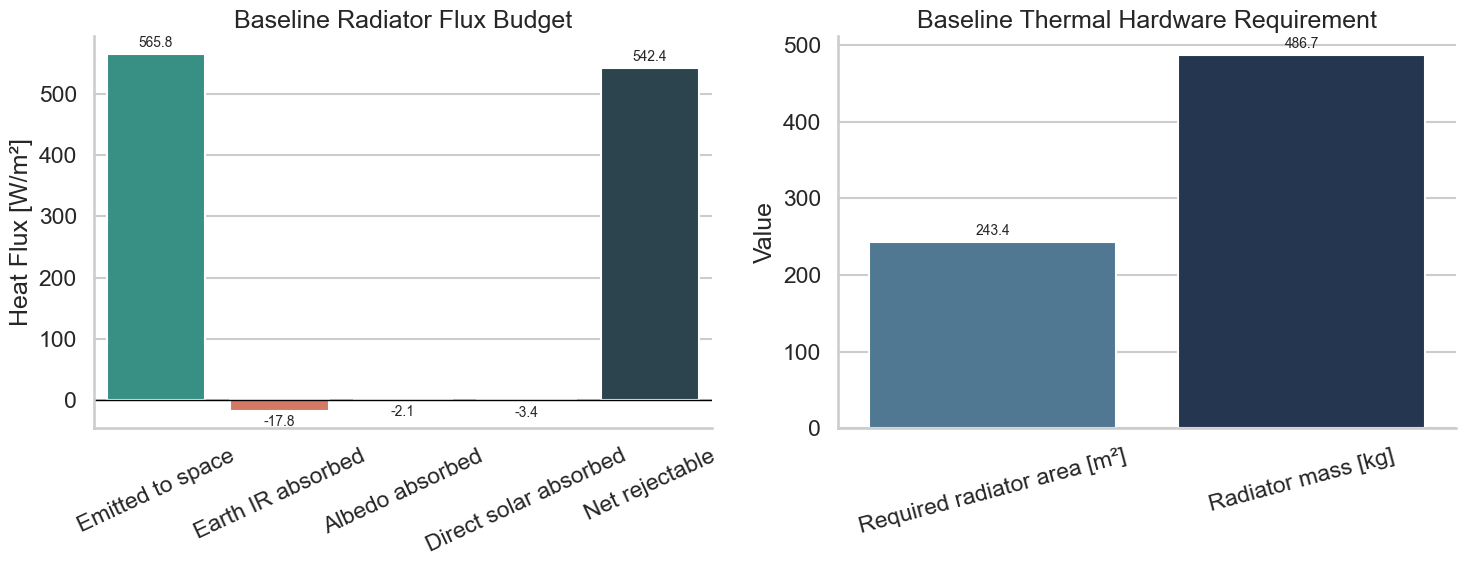

In [23]:
thermal_components = pd.DataFrame([
    {'component': 'Emitted to space', 'flux_w_m2': RAD_DIAG_BASE['q_emit_w_m2'], 'type': 'positive'},
    {'component': 'Earth IR absorbed', 'flux_w_m2': -RAD_DIAG_BASE['q_backload_earth_ir_w_m2'], 'type': 'backload'},
    {'component': 'Albedo absorbed', 'flux_w_m2': -RAD_DIAG_BASE['q_backload_albedo_w_m2'], 'type': 'backload'},
    {'component': 'Direct solar absorbed', 'flux_w_m2': -RAD_DIAG_BASE['q_backload_solar_w_m2'], 'type': 'backload'},
    {'component': 'Net rejectable', 'flux_w_m2': RAD_DIAG_BASE['q_net_w_m2'], 'type': 'net'},
])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

palette = {
    'positive': '#2a9d8f',
    'backload': '#e76f51',
    'net': '#264653',
}

sns.barplot(
    data=thermal_components,
    x='component',
    y='flux_w_m2',
    hue='type',
    dodge=False,
    palette=palette,
    ax=axes[0],
)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_ylabel('Heat Flux [W/m²]')
axes[0].set_xlabel('')
axes[0].set_title('Baseline Radiator Flux Budget')
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend([], [], frameon=False)

area_mass_df = pd.DataFrame([
    {'metric': 'Required radiator area [m²]', 'value': A_RAD_M2},
    {'metric': 'Radiator mass [kg]', 'value': M_RAD_KG},
])
sns.barplot(data=area_mass_df, x='metric', y='value', palette=['#457b9d', '#1d3557'], ax=axes[1])
axes[1].set_xlabel('')
axes[1].set_ylabel('Value')
axes[1].set_title('Baseline Thermal Hardware Requirement')
axes[1].tick_params(axis='x', rotation=15)

for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', padding=3, fontsize=10)

plt.tight_layout()
plt.show()

## 2) GPU operating temperature and radiator sizing

### Why GPU junction temperature is the key thermal knob

In a space-based server the only way to reject heat is radiation, and the Stefan–Boltzmann law tells us that radiated power per unit area scales as $T^4$.
The temperature that matters for radiator sizing is the **radiator surface temperature**, which is set by the GPU junction temperature minus a thermal-resistance drop through the heat-transport path:

$$T_{\text{rad}} = T_{\text{GPU,junction}} - \Delta T_{\text{transport}}$$

Our baseline uses $T_{\text{GPU}} = 90\,$°C (representative of modern data-center GPUs such as the NVIDIA H100/B200 family, whose maximum junction spec is ≈ 83–90 °C) and a transport drop $\Delta T = 30\,$°C, giving $T_{\text{rad}} = 60\,$°C.

**What is realistic?**

| GPU Temp (°C) | Radiator Temp (°C) | Interpretation |
|:---:|:---:|:---|
| 70 – 80 | 40 – 50 | Conservative / terrestrial-like. Radiators become very large. |
| **80 – 90** | **50 – 60** | **Matches current NVIDIA data-center silicon specs. Good baseline.** |
| 90 – 105 | 60 – 75 | Pushing specs — possible with hardened or custom silicon, or accepting shorter GPU life. |
| 105 – 130 | 75 – 100 | Speculative — purpose-built space compute chips. Dramatic radiator reduction but unproven. |

Because of the $T^4$ scaling, even a modest increase in allowable GPU temperature produces outsized savings in radiator area, mass, and ultimately cost.
The plots below quantify this: first the pure thermal sensitivity, then the full satellite-level cost impact per degree.

### Radiator area and mass vs GPU temperature

We vary GPU temperature and see how radiator area/mass changes, holding power constant and `ΔT_to_radiator` fixed.


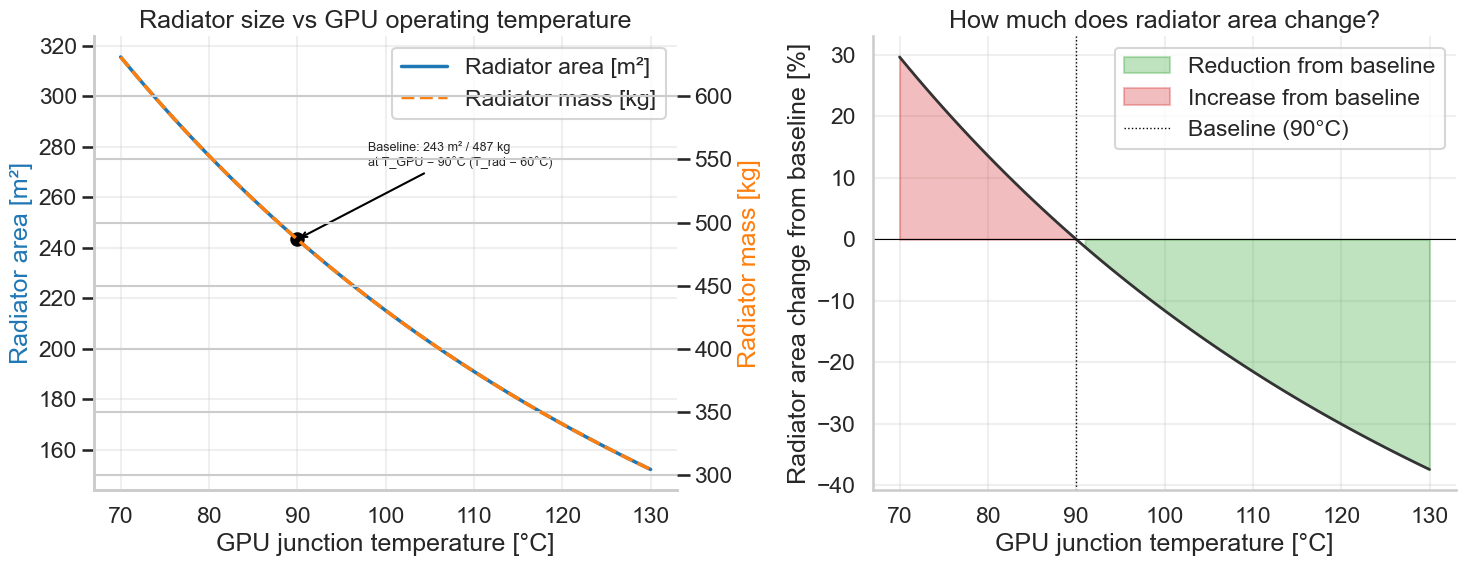

Reference points (radiator area and mass at selected GPU temperatures):
  GPU °C    Rad °C     Area m²     Mass kg   Δ vs baseline
      70        40       315.6       631.1          +29.7%
      80        50       276.5       552.9          +13.6%
      90        60       243.4       486.7           +0.0% (baseline)
     100        70       215.2       430.4          -11.6%
     110        80       191.0       382.1          -21.5%
     120        90       170.2       340.5          -30.1%
     130       100       152.2       304.5          -37.4%


In [24]:
# ---- Sweep GPU temperature for radiator sizing ----
gpu_temps = np.linspace(70, 130, 61)  # °C
rad_temps = gpu_temps - DELTA_T_TO_RADIATOR_C

areas = []
for t in rad_temps:
    a, _ = radiator_area_m2_with_backload(
        q_internal_w=P_LOAD_W,
        t_rad_c=t,
        alt_km=ALT_BASELINE_KM,
        beta_deg=BETA_DEG,
        epsilon=EPSILON,
        t_sink_k=T_SINK_K,
        k_eff=K_EFFECTIVE,
        alpha_solar=ALPHA_SOLAR,
        alpha_ir=ALPHA_IR,
        earth_ir_flux_w_m2=EARTH_IR_FLUX_W_PER_M2,
        earth_bond_albedo=EARTH_BOND_ALBEDO,
        earth_view_fraction_of_max=EARTH_VIEW_FRACTION_OF_MAX,
        radiator_solar_view_factor=RADIATOR_SOLAR_VIEW_FACTOR,
        albedo_geometry_factor=ALBEDO_GEOMETRY_FACTOR,
    )
    areas.append(a)

areas = np.array(areas)
masses = areas * RADIATOR_AREAL_DENSITY
baseline_idx = np.argmin(np.abs(gpu_temps - T_GPU_C))

# --- Figure 1: area and mass vs GPU temperature (dual axis) ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax1 = axes[0]
ax1b = ax1.twinx()
l1 = ax1.plot(gpu_temps, areas, color='#1f77b4', linewidth=2.5, label='Radiator area [m²]')
l2 = ax1b.plot(gpu_temps, masses, color='#ff7f0e', linewidth=2.5, linestyle='--', label='Radiator mass [kg]')
ax1.scatter(gpu_temps[baseline_idx], areas[baseline_idx], color='black', zorder=5, s=80)
ax1.annotate(
    f'Baseline: {areas[baseline_idx]:.0f} m² / {masses[baseline_idx]:.0f} kg\n'
    f'at T_GPU = {gpu_temps[baseline_idx]:.0f}°C (T_rad = {rad_temps[baseline_idx]:.0f}°C)',
    xy=(gpu_temps[baseline_idx], areas[baseline_idx]),
    xytext=(gpu_temps[baseline_idx] + 8, areas[baseline_idx] * 1.12),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=9,
)
ax1.set_xlabel('GPU junction temperature [°C]')
ax1.set_ylabel('Radiator area [m²]', color='#1f77b4')
ax1b.set_ylabel('Radiator mass [kg]', color='#ff7f0e')
ax1.set_title('Radiator size vs GPU operating temperature')
lines = l1 + l2
ax1.legend(lines, [l.get_label() for l in lines], loc='upper right')
ax1.grid(True, alpha=0.3)

# --- Figure 2: % reduction from baseline ---
baseline_area = areas[baseline_idx]
pct_change = 100.0 * (areas - baseline_area) / baseline_area

ax2 = axes[1]
ax2.fill_between(gpu_temps, pct_change, 0, where=(pct_change < 0),
                 color='#2ca02c', alpha=0.3, label='Reduction from baseline')
ax2.fill_between(gpu_temps, pct_change, 0, where=(pct_change >= 0),
                 color='#d62728', alpha=0.3, label='Increase from baseline')
ax2.plot(gpu_temps, pct_change, color='#333333', linewidth=2)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.axvline(T_GPU_C, color='black', linewidth=1, linestyle=':', label=f'Baseline ({T_GPU_C:.0f}°C)')
ax2.set_xlabel('GPU junction temperature [°C]')
ax2.set_ylabel('Radiator area change from baseline [%]')
ax2.set_title('How much does radiator area change?')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print a few reference points
print('Reference points (radiator area and mass at selected GPU temperatures):')
print(f'{"GPU °C":>8s}  {"Rad °C":>8s}  {"Area m²":>10s}  {"Mass kg":>10s}  {"Δ vs baseline":>14s}')
for t_gpu in [70, 80, 90, 100, 110, 120, 130]:
    idx = np.argmin(np.abs(gpu_temps - t_gpu))
    delta = 100.0 * (areas[idx] - baseline_area) / baseline_area
    tag = ' (baseline)' if abs(gpu_temps[idx] - T_GPU_C) < 0.5 else ''
    print(f'{gpu_temps[idx]:8.0f}  {rad_temps[idx]:8.0f}  {areas[idx]:10.1f}  {masses[idx]:10.1f}  {delta:+13.1f}%{tag}')


### Satellite cost savings per degree of GPU temperature

The radiator is not just mass — it propagates into launch cost, structural mass fraction, and radiator hardware cost.
Below we compute the **full satellite CAPEX** at each GPU temperature (holding everything else constant at the baseline orbit) and plot:

1. Total satellite cost vs GPU temperature.
2. **Marginal cost savings per additional degree** — i.e., how much cheaper the satellite gets for each +1°C of allowable GPU temperature.

This directly answers: *"Is it worth investing in thermal design to allow hotter GPU operation?"*


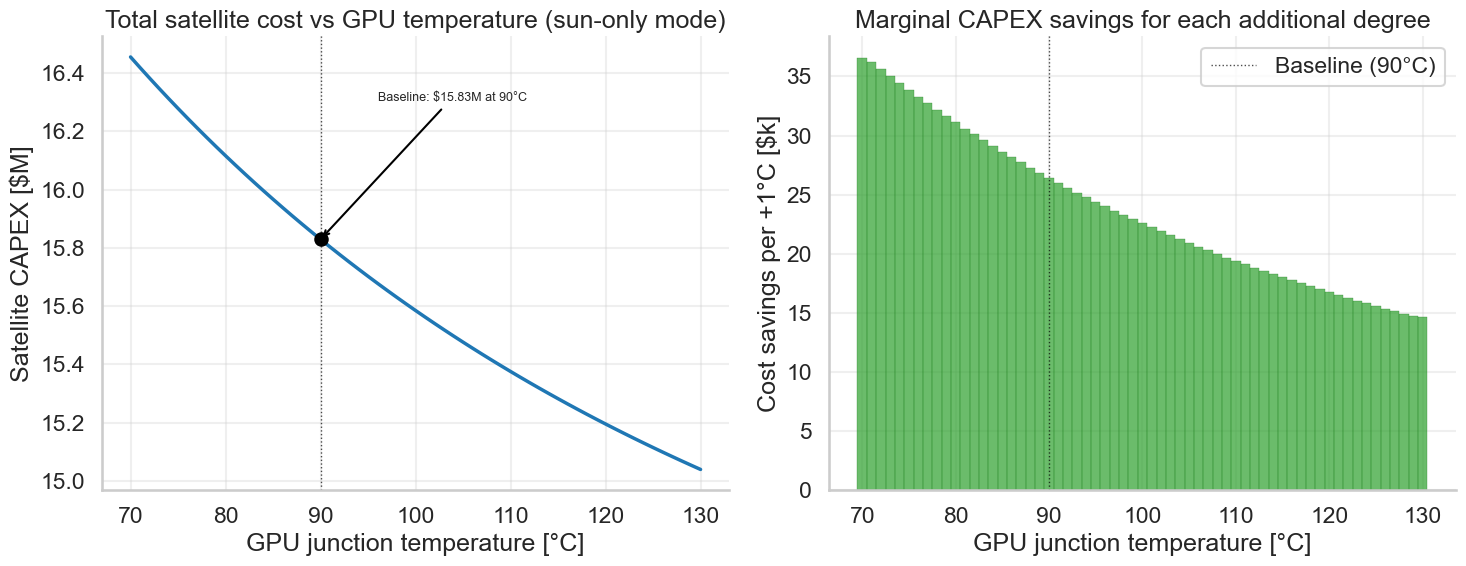


Satellite cost at selected GPU temperatures (sun-only, baseline orbit):
  GPU °C    Rad °C    Rad m²    Total kg    CAPEX $M   Δ vs baseline   Savings/°C $k
      70        40     315.6      2721.5      16.455           +4.0%            36.6
      80        50     276.5      2617.2      16.116           +1.8%            31.1
      85        55     259.2      2571.3      15.967           +0.9%            28.6
      90        60     243.4      2529.0      15.829           +0.0%            26.4 *
      95        65     228.7      2489.9      15.702           -0.8%            24.4
     100        70     215.2      2453.8      15.585           -1.5%            22.6
     110        80     191.0      2389.4      15.376           -2.9%            19.4
     120        90     170.2      2334.0      15.195           -4.0%            16.7
     130       100     152.2      2286.0      15.039           -5.0%            14.6


In [25]:
# ---- Full satellite cost vs GPU temperature ----
def satellite_cost_at_gpu_temp(t_gpu_c: float) -> dict:
    """Compute full satellite mass breakdown and CAPEX for a given GPU junction temp."""
    t_rad_c = t_gpu_c - DELTA_T_TO_RADIATOR_C
    beta = BETA_DEG
    f = sunlight_fraction(ALT_BASELINE_KM, beta)

    a_rad, rad_diag = radiator_area_m2_with_backload(
        q_internal_w=P_LOAD_W,
        t_rad_c=t_rad_c,
        alt_km=ALT_BASELINE_KM,
        beta_deg=beta,
        epsilon=EPSILON,
        t_sink_k=T_SINK_K,
        k_eff=K_EFFECTIVE,
        alpha_solar=ALPHA_SOLAR,
        alpha_ir=ALPHA_IR,
        earth_ir_flux_w_m2=EARTH_IR_FLUX_W_PER_M2,
        earth_bond_albedo=EARTH_BOND_ALBEDO,
        earth_view_fraction_of_max=EARTH_VIEW_FRACTION_OF_MAX,
        radiator_solar_view_factor=RADIATOR_SOLAR_VIEW_FACTOR,
        albedo_geometry_factor=ALBEDO_GEOMETRY_FACTOR,
    )
    m_rad = a_rad * RADIATOR_AREAL_DENSITY

    # Sun-only mode for simplicity (isolates thermal effect)
    p_array = P_LOAD_W
    m_array = p_array / ARRAY_SPECIFIC_POWER_W_PER_KG

    m_nonbus = M_COMPUTE_KG + m_rad + m_array
    m_total = total_mass_with_bus(m_nonbus, BUS_MASS_FRACTION_OF_TOTAL)

    compute_cost = COMPUTE_COST_PER_KW * P_COMPUTE_KW
    array_cost = p_array * ARRAY_COST_PER_W
    rad_cost = a_rad * RADIATOR_COST_PER_M2
    cost_per_kg = effective_cost_per_kg_to_altitude(
        ALT_BASELINE_KM, ALT_BASELINE_KM, COST_TO_BASELINE_PER_KG,
        ISP_TRANSFER_S, PROPULSION_STRUCT_FRAC,
    )
    launch_cost = m_total * cost_per_kg
    capex = compute_cost + array_cost + rad_cost + BUS_COST_FIXED + launch_cost

    return {
        't_gpu_c': t_gpu_c,
        't_rad_c': t_rad_c,
        'a_rad_m2': a_rad,
        'm_rad_kg': m_rad,
        'm_total_kg': m_total,
        'capex_usd': capex,
        'launch_cost_usd': launch_cost,
        'rad_cost_usd': rad_cost,
    }

# Fine-grained sweep (1°C steps)
gpu_temps_fine = np.arange(70, 131, 1.0)
cost_rows = [satellite_cost_at_gpu_temp(t) for t in gpu_temps_fine]
cost_df = pd.DataFrame(cost_rows)

# Marginal savings: Δcost for each +1°C
cost_df['marginal_savings_usd_per_deg'] = -np.gradient(cost_df['capex_usd'], cost_df['t_gpu_c'])

baseline_cost = cost_df.loc[cost_df['t_gpu_c'] == T_GPU_C, 'capex_usd'].values[0]

# ---- Figure: two subplots ----
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: total satellite cost
ax1 = axes[0]
ax1.plot(cost_df['t_gpu_c'], cost_df['capex_usd'] / 1e6, color='#1f77b4', linewidth=2.5)
ax1.axvline(T_GPU_C, color='black', linewidth=1, linestyle=':', alpha=0.7)
ax1.scatter([T_GPU_C], [baseline_cost / 1e6], color='black', zorder=5, s=80)
ax1.annotate(
    f'Baseline: ${baseline_cost/1e6:.2f}M at {T_GPU_C:.0f}°C',
    xy=(T_GPU_C, baseline_cost / 1e6),
    xytext=(T_GPU_C + 6, baseline_cost / 1e6 * 1.03),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=9,
)
ax1.set_xlabel('GPU junction temperature [°C]')
ax1.set_ylabel('Satellite CAPEX [$M]')
ax1.set_title('Total satellite cost vs GPU temperature (sun-only mode)')
ax1.grid(True, alpha=0.3)

# Right: marginal savings per degree
ax2 = axes[1]
ax2.bar(cost_df['t_gpu_c'], cost_df['marginal_savings_usd_per_deg'] / 1e3,
        width=1.0, color='#2ca02c', alpha=0.7, edgecolor='#1a7a1a', linewidth=0.3)
ax2.axvline(T_GPU_C, color='black', linewidth=1, linestyle=':', alpha=0.7,
            label=f'Baseline ({T_GPU_C:.0f}°C)')
ax2.set_xlabel('GPU junction temperature [°C]')
ax2.set_ylabel('Cost savings per +1°C [$k]')
ax2.set_title('Marginal CAPEX savings for each additional degree')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary table
print('\nSatellite cost at selected GPU temperatures (sun-only, baseline orbit):')
print(f'{"GPU °C":>8s}  {"Rad °C":>8s}  {"Rad m²":>8s}  {"Total kg":>10s}  '
      f'{"CAPEX $M":>10s}  {"Δ vs baseline":>14s}  {"Savings/°C $k":>14s}')
for t_gpu in [70, 80, 85, 90, 95, 100, 110, 120, 130]:
    row = cost_df.loc[cost_df['t_gpu_c'] == t_gpu].iloc[0]
    delta_pct = 100.0 * (row['capex_usd'] - baseline_cost) / baseline_cost
    tag = ' *' if abs(t_gpu - T_GPU_C) < 0.5 else ''
    print(f'{row["t_gpu_c"]:8.0f}  {row["t_rad_c"]:8.0f}  {row["a_rad_m2"]:8.1f}  '
          f'{row["m_total_kg"]:10.1f}  {row["capex_usd"]/1e6:10.3f}  '
          f'{delta_pct:+13.1f}%  {row["marginal_savings_usd_per_deg"]/1e3:14.1f}{tag}')


## 3) Sunlight availability vs altitude and orbital geometry

The thermal analysis above tells us *how much radiator we need per watt*. But the question of *how many watts we can actually generate* depends on how often our satellites see the Sun. In space, solar arrays are the only practical power source at this scale, and they only work when sunlit. Since we have committed to sunlight-only operation, every minute a satellite spends in Earth's shadow is a minute of compute downtime — so maximizing sunlight fraction directly maximizes per-satellite throughput.

Two geometric factors dominate sunlight availability:

### Altitude: higher orbits see shorter eclipses

A satellite in a circular orbit traces a great circle around the Earth at a fixed altitude. Each orbit, it passes through Earth's shadow cone — an "eclipse." The key insight is geometric: as altitude increases, the orbit gets larger but Earth stays the same size. The shadow subtends a smaller fraction of the orbit, so eclipses get shorter relative to the orbital period.

At LEO altitudes (400–600 km), a worst-case eclipse can last ~36 minutes out of a ~95-minute orbit — roughly 38% of each orbit in darkness. By 2,000 km, the shadow fraction drops noticeably. Above ~10,000 km, eclipses become quite short relative to the much longer orbital period.

### Beta angle ($\beta$): the orbit-plane geometry relative to the Sun

The **beta angle** is the angle between the Sun's direction and the satellite's orbital plane. It is the single most important geometric parameter for sunlight availability:

- **$\beta = 0°$ (Sun in the orbital plane)**: the satellite flies directly into and out of Earth's shadow every orbit. This is the *worst-case eclipse season* — maximum shadow time.
- **$\beta = 90°$ (Sun perpendicular to the orbital plane)**: the orbit is "edge-on" to the Sun. The satellite can fly over the sunlit face of the Earth continuously, never entering the shadow. This is the **dawn-dusk** geometry — permanent sunlight.
- **Intermediate $\beta$ values**: the eclipse gets progressively shorter as $\beta$ increases, until a critical angle (which depends on altitude) where eclipses vanish entirely.

For any given altitude, there is a threshold beta angle above which the satellite is in permanent sunlight. This threshold is lower at higher altitudes (because the shadow cone is relatively smaller).

### Sunlight fraction ($f_{sun}$)

We define **sunlight fraction** as the fraction of each orbit spent in sunlight. Using a simple **cylindrical Earth-shadow model** (which treats the shadow as a cylinder rather than a cone — a good first-order approximation), we compute $f_{sun}$ as a function of altitude and $\beta$.

- $f_{sun} = 1.0$ means continuous sunlight (no eclipse).
- Lower $f_{sun}$ means longer eclipses and proportionally less compute time per orbit.

Below, we visualize $f_{sun}$ in two ways:
1. A **heatmap** over altitude and beta angle — showing the full landscape of sunlight geometry.
2. A **slice at the baseline beta** ($\beta = 0°$, worst case) — showing how altitude alone improves eclipse duration.

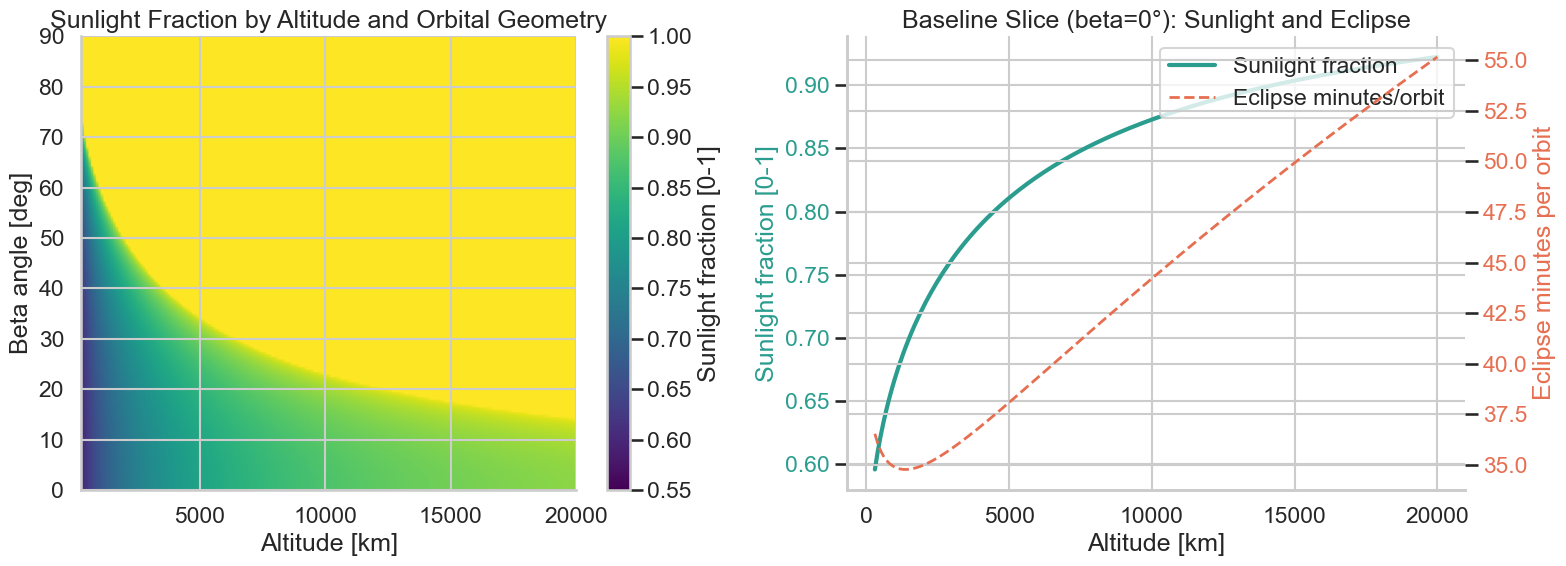

In [26]:
alts = np.linspace(300, 20_000, 200)  # km
betas = np.linspace(0, 90, 181)      # deg

sun_grid = np.array([[sunlight_fraction(a, b) for a in alts] for b in betas])

# Baseline-beta slice
f_sun = np.array([sunlight_fraction(a, BETA_DEG) for a in alts])
period = np.array([orbital_period_s(a) for a in alts])
eclipse_min = (1 - f_sun) * period / 60.0

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

hm = axes[0].imshow(
    sun_grid,
    aspect='auto',
    origin='lower',
    extent=[alts.min(), alts.max(), betas.min(), betas.max()],
    cmap='viridis',
    vmin=0.55,
    vmax=1.0,
)
axes[0].set_xlabel('Altitude [km]')
axes[0].set_ylabel('Beta angle [deg]')
axes[0].set_title('Sunlight Fraction by Altitude and Orbital Geometry')
cbar = plt.colorbar(hm, ax=axes[0])
cbar.set_label('Sunlight fraction [0-1]')

axes[1].plot(alts, f_sun, color='#2a9d8f', linewidth=3, label='Sunlight fraction')
axes[1].set_xlabel('Altitude [km]')
axes[1].set_ylabel('Sunlight fraction [0-1]', color='#2a9d8f')
axes[1].tick_params(axis='y', labelcolor='#2a9d8f')
axes[1].set_title(f'Baseline Slice (beta={BETA_DEG:.0f}°): Sunlight and Eclipse')

ax2 = axes[1].twinx()
ax2.plot(alts, eclipse_min, color='#e76f51', linewidth=2, linestyle='--', label='Eclipse minutes/orbit')
ax2.set_ylabel('Eclipse minutes per orbit', color='#e76f51')
ax2.tick_params(axis='y', labelcolor='#e76f51')

handles1, labels1 = axes[1].get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(handles1 + handles2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

## 4) Internet-service sunlight scenarios and constellation view

### Why a single satellite's geometry doesn't tell the whole story

If we were designing a single experimental satellite, we could pick the most favorable orbit — a dawn-dusk sun-synchronous orbit at high beta angle, giving near-continuous sunlight. But an LLM inference constellation is not a single satellite. It needs to serve users across different geographic regions and local times, which forces a spread of orbital planes.

### What drives constellation geometry

A satellite's ground coverage footprint is determined by its altitude — higher orbits see more of the Earth's surface at once. But to provide continuous, low-latency service to users across the globe, a constellation distributes satellites across many **orbital planes**. Each plane has a different orientation defined by its **RAAN** (Right Ascension of the Ascending Node — essentially, which direction the orbital plane faces in space).

Because the Sun illuminates Earth from a fixed direction at any given time, different orbital planes naturally have different **beta angles**:
- Planes aligned near the dawn-dusk terminator enjoy high $\beta$ and near-continuous sunlight.
- Planes oriented perpendicular to this (flying "into" and "away from" the Sun) have low $\beta$ and experience full eclipses.

A constellation designed for global coverage cannot avoid low-beta planes — it needs them for geographic coverage. The result is a **mix of beta angles across the fleet**, which is what we model here.

### The constellation beta mix

Rather than modeling every individual orbital plane, we use a simplified **weighted beta mix**: a set of representative beta angles and the fraction of the fleet operating near each one. Our default mix (`CONSTELLATION_BETA_MIX`) is:

| Beta bin | Weight | Interpretation |
|----------|--------|---------------|
| 0° | 30% | Worst-case eclipse season planes |
| 30° | 45% | Moderate geometry (most planes) |
| 60° | 20% | High-beta, favorable planes |
| 90° | 5% | Ideal dawn-dusk (rare in coverage-optimized designs) |

This mix reflects a practical reality: most planes in a large coverage constellation will sit at moderate beta angles, with only a small fraction achieving ideal dawn-dusk conditions.

### What we compute below

For each beta scenario and the weighted constellation mix, we show:
1. **Sunlight fraction vs. altitude** — how much each geometry benefits from going higher, and what the fleet-average looks like under our constellation beta mix.
2. **Communications tradeoffs** — a compact table of ground footprint radius and one-way propagation delay at representative altitudes, to anchor the altitude choice in real service constraints.

The key question for constellation design: *at what altitude does the fleet-average sunlight fraction become high enough that eclipse downtime is a minor concern?*

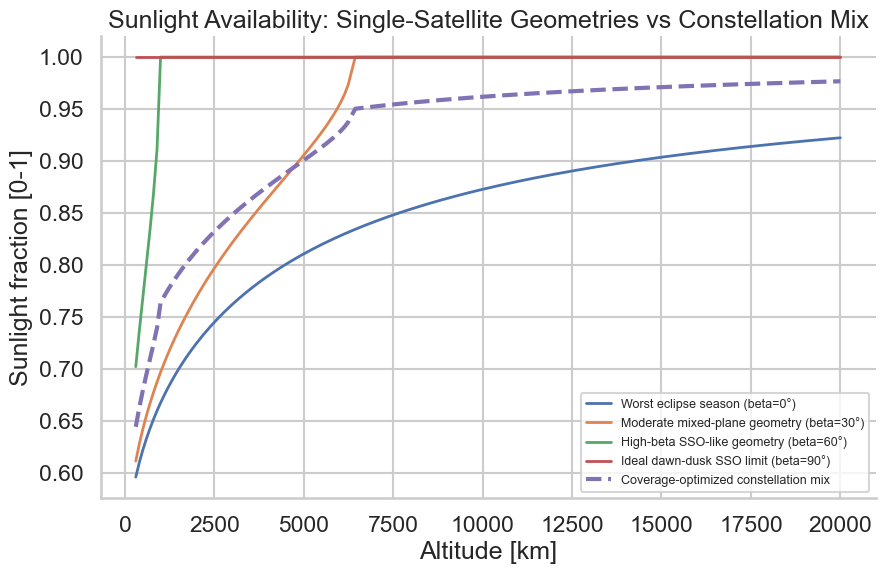

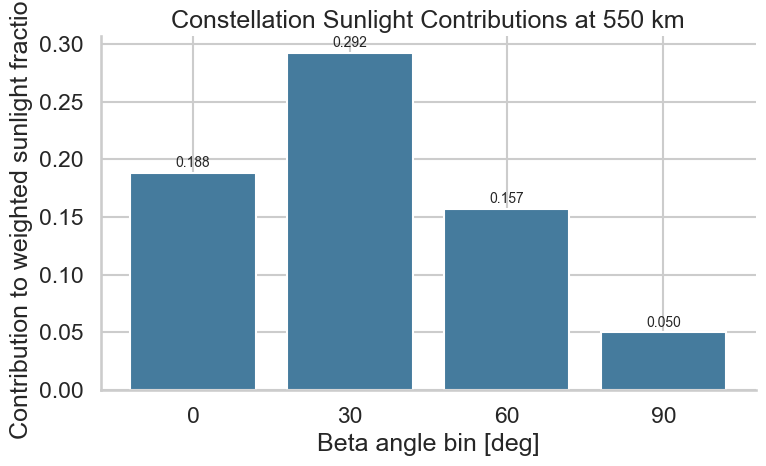

,alt_km,max_ground_footprint_radius_km,one_way_nadir_propagation_ms
0,550,2557.045290,1.834603
1,700,2858.780716,2.334949
2,1000,3357.347100,3.335641
3,2000,4496.779115,6.671282
4,10000,7460.904211,33.356410


In [27]:
# Scenario set to represent different operational constellation geometries.
SUNLIGHT_SCENARIOS = [
    ('Worst eclipse season (beta=0°)', 0.0),
    ('Moderate mixed-plane geometry (beta=30°)', 30.0),
    ('High-beta SSO-like geometry (beta=60°)', 60.0),
    ('Ideal dawn-dusk SSO limit (beta=90°)', 90.0),
]

# Coverage-oriented constellation mix across planes (from model knobs).
CONSTELLATION_MIX = normalize_beta_mix(CONSTELLATION_BETA_MIX)

scenario_rows = []
for alt in alts:
    t_orbit_s = orbital_period_s(alt)

    for scenario_name, beta in SUNLIGHT_SCENARIOS:
        f = sunlight_fraction(alt, beta)
        eclipse_min = (1.0 - f) * t_orbit_s / 60.0
        scenario_rows.append({
            'scenario': scenario_name,
            'beta_deg': beta,
            'alt_km': alt,
            'sunlight_fraction': f,
            'eclipse_min': eclipse_min,
        })

    mix_metrics = constellation_sunlight_metrics(alt, CONSTELLATION_MIX)
    scenario_rows.append({
        'scenario': 'Coverage-optimized constellation mix',
        'beta_deg': np.nan,
        'alt_km': alt,
        'sunlight_fraction': mix_metrics['sunlight_fraction_weighted'],
        'eclipse_min': mix_metrics['eclipse_min_weighted'],
    })

sun_df = pd.DataFrame(scenario_rows)

plt.figure(figsize=(10, 6))
for name in sun_df['scenario'].unique():
    s = sun_df[sun_df['scenario'] == name]
    style = '--' if name == 'Coverage-optimized constellation mix' else '-'
    width = 3 if name == 'Coverage-optimized constellation mix' else 2
    plt.plot(s['alt_km'], s['sunlight_fraction'], linestyle=style, linewidth=width, label=name)

plt.xlabel('Altitude [km]')
plt.ylabel('Sunlight fraction [0-1]')
plt.title('Sunlight Availability: Single-Satellite Geometries vs Constellation Mix')
plt.legend(fontsize=9)
plt.grid(True)
plt.show()

# Show a compact table at representative altitudes for blog readability.
mix_table_rows = []
for alt in [550, 700, 1000, 2000]:
    m = constellation_sunlight_metrics(alt, CONSTELLATION_MIX)
    mix_table_rows.append({
        'alt_km': alt,
        'weighted_sunlight_fraction': m['sunlight_fraction_weighted'],
        'weighted_eclipse_min': m['eclipse_min_weighted'],
    })
mix_table = pd.DataFrame(mix_table_rows)
mix_table

# Beta-mix contribution chart at baseline altitude.
mix_contrib_rows = []
for beta, w in CONSTELLATION_MIX:
    f = sunlight_fraction(ALT_BASELINE_KM, beta)
    mix_contrib_rows.append({
        'beta_deg': beta,
        'mix_weight': w,
        'sunlight_fraction': f,
        'weighted_contribution': w * f,
    })

mix_contrib = pd.DataFrame(mix_contrib_rows)
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(mix_contrib['beta_deg'].astype(int).astype(str), mix_contrib['weighted_contribution'], color='#457b9d')
ax.set_xlabel('Beta angle bin [deg]')
ax.set_ylabel('Contribution to weighted sunlight fraction')
ax.set_title(f'Constellation Sunlight Contributions at {ALT_BASELINE_KM:.0f} km')
for i, v in enumerate(mix_contrib['weighted_contribution']):
    ax.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

# Simple communications tradeoff proxies for Earth internet service.
C_LIGHT_M_PER_S = 299_792_458.0
comm_rows = []
for alt in [550, 700, 1000, 2000, 10_000]:
    r = R_EARTH + 1_000.0 * alt
    horizon_half_angle_rad = np.arccos(R_EARTH / r)
    ground_footprint_radius_km = (R_EARTH * horizon_half_angle_rad) / 1000.0
    one_way_nadir_ms = (1_000.0 * alt / C_LIGHT_M_PER_S) * 1_000.0
    comm_rows.append({
        'alt_km': alt,
        'max_ground_footprint_radius_km': ground_footprint_radius_km,
        'one_way_nadir_propagation_ms': one_way_nadir_ms,
    })

pd.DataFrame(comm_rows)

## 5) Mass and cost vs altitude

With sunlight-only operation locked in, we now sweep altitude to see how satellite mass and cost scale. Higher orbits improve sunlight fraction (Section 3), but they also impose an altitude-related launch premium.

To make that premium easier to interpret, we track three related quantities alongside total satellite CAPEX:

1. The **delivered launch cost** in `$/kg` to the final orbit.
2. The **incremental altitude premium** in `$/kg delivered` relative to the `550 km` baseline.
3. An **average implied `$/kg/km`** over the full altitude increase, used only as a reader-friendly heuristic.

The first two are the economically meaningful quantities. The third is included because it is intuitive for readers, but it should not be mistaken for a constant physical law.


In [28]:
def satellite_mass_breakdown(alt_km: float, mode: str, beta_deg=None) -> dict:
    """Return mass breakdown for a single satellite at altitude for a given mode."""
    beta = BETA_DEG if beta_deg is None else float(beta_deg)
    f = sunlight_fraction(alt_km, beta)

    # Radiator mass includes orbit-dependent thermal backload.
    a_rad, rad_diag = radiator_area_m2_with_backload(
        q_internal_w=P_LOAD_W,
        t_rad_c=T_RAD_C,
        alt_km=alt_km,
        beta_deg=beta,
        epsilon=EPSILON,
        t_sink_k=T_SINK_K,
        k_eff=K_EFFECTIVE,
        alpha_solar=ALPHA_SOLAR,
        alpha_ir=ALPHA_IR,
        earth_ir_flux_w_m2=EARTH_IR_FLUX_W_PER_M2,
        earth_bond_albedo=EARTH_BOND_ALBEDO,
        earth_view_fraction_of_max=EARTH_VIEW_FRACTION_OF_MAX,
        radiator_solar_view_factor=RADIATOR_SOLAR_VIEW_FACTOR,
        albedo_geometry_factor=ALBEDO_GEOMETRY_FACTOR,
    )
    m_rad = a_rad * RADIATOR_AREAL_DENSITY

    if mode == "sunonly":
        p_array = P_LOAD_W
        m_array = p_array / ARRAY_SPECIFIC_POWER_W_PER_KG
        m_batt = 0.0
        uptime = f
    elif mode == "247":
        p_array = P_LOAD_W / max(f, 1e-6)
        m_array = p_array / ARRAY_SPECIFIC_POWER_W_PER_KG

        t_orbit = orbital_period_s(alt_km)
        t_eclipse = (1 - f) * t_orbit
        e_batt_wh = (P_LOAD_W/1000) * (t_eclipse/3600) / (BATTERY_ROUND_TRIP_EFF * BATTERY_DOD) * 1000
        m_batt = e_batt_wh / BATTERY_SPECIFIC_ENERGY_WH_PER_KG
        uptime = 1.0
    else:
        raise ValueError("mode must be 'sunonly' or '247'")

    m_nonbus = M_COMPUTE_KG + m_rad + m_array + m_batt
    m_total = total_mass_with_bus(m_nonbus, BUS_MASS_FRACTION_OF_TOTAL)

    avg_compute_kw = P_COMPUTE_KW * uptime

    return {
        "alt_km": alt_km,
        "mode": mode,
        "beta_deg": beta,
        "sunlight_fraction": f,
        "uptime_fraction": uptime,
        "m_compute_kg": M_COMPUTE_KG,
        "a_radiator_m2": a_rad,
        "m_radiator_kg": m_rad,
        "q_backload_w_m2": rad_diag["q_backload_total_w_m2"],
        "q_net_radiator_w_m2": rad_diag["q_net_w_m2"],
        "m_array_kg": m_array,
        "m_battery_kg": m_batt,
        "m_total_kg": m_total,
        "p_array_peak_w": p_array,
        "avg_compute_kw": avg_compute_kw,
        "specific_compute_w_per_kg": (1_000.0 * P_COMPUTE_KW) / m_total,
        "specific_load_w_per_kg": P_LOAD_W / m_total,
    }

def satellite_capex_usd(breakdown: dict) -> float:
    """Very simplified CAPEX: compute ($/kW coupled) + arrays + radiators + batteries + bus + launch."""
    compute_cost = COMPUTE_COST_PER_KW * P_COMPUTE_KW

    array_cost = breakdown["p_array_peak_w"] * ARRAY_COST_PER_W
    rad_cost = breakdown["a_radiator_m2"] * RADIATOR_COST_PER_M2
    batt_cost = (breakdown["m_battery_kg"] * BATTERY_SPECIFIC_ENERGY_WH_PER_KG / 1000) * BATTERY_COST_PER_KWH  # kWh

    cost_per_kg = effective_cost_per_kg_to_altitude(
        breakdown["alt_km"], ALT_BASELINE_KM, COST_TO_BASELINE_PER_KG,
        ISP_TRANSFER_S, PROPULSION_STRUCT_FRAC,
    )
    launch_cost = breakdown["m_total_kg"] * cost_per_kg

    return float(compute_cost + array_cost + rad_cost + batt_cost + BUS_COST_FIXED + launch_cost)

alts_cost = np.linspace(ALT_BASELINE_KM, 20_000, 220)

rows = []
for a in alts_cost:
    b = satellite_mass_breakdown(a, "sunonly")
    capex = satellite_capex_usd(b)
    cost_per_kg = effective_cost_per_kg_to_altitude(
        a, ALT_BASELINE_KM, COST_TO_BASELINE_PER_KG,
        ISP_TRANSFER_S, PROPULSION_STRUCT_FRAC,
    )
    altitude_premium_per_kg = cost_per_kg - COST_TO_BASELINE_PER_KG
    delta_alt_km = max(a - ALT_BASELINE_KM, 0.0)

    b["launch_cost_per_kg_usd"] = cost_per_kg
    b["launch_mass_multiplier"] = cost_per_kg / COST_TO_BASELINE_PER_KG
    b["altitude_premium_per_kg_usd"] = altitude_premium_per_kg
    b["avg_altitude_premium_usd_per_kg_per_km"] = (
        altitude_premium_per_kg / delta_alt_km if delta_alt_km > 0 else 0.0
    )
    b["altitude_premium_per_sat_usd"] = altitude_premium_per_kg * b["m_total_kg"]
    b["capex_usd"] = capex
    b["capex_per_avg_compute_kw_usd_per_kw"] = capex / max(b["avg_compute_kw"], 1e-9)
    rows.append(b)

df = pd.DataFrame(rows)
df.head()


,alt_km,mode,beta_deg,sunlight_fraction,uptime_fraction,m_compute_kg,a_radiator_m2,m_radiator_kg,q_backload_w_m2,q_net_radiator_w_m2,...,avg_compute_kw,specific_compute_w_per_kg,specific_load_w_per_kg,launch_cost_per_kg_usd,launch_mass_multiplier,altitude_premium_per_kg_usd,avg_altitude_premium_usd_per_kg_per_km,altitude_premium_per_sat_usd,capex_usd,capex_per_avg_compute_kw_usd_per_kw
0,550.000000,sunonly,0.0,0.627756,0.627756,750.0,243.363197,486.726393,23.391798,542.399187,...,75.330707,47.450175,52.195193,2500.000000,1.000000,0.000000,0.000000,0.000000,1.582915e+07,210128.754901
1,638.812785,sunonly,0.0,0.636947,0.636947,750.0,243.173770,486.347541,22.969282,542.821702,...,76.433673,47.459655,52.205620,2543.444825,1.017378,43.444825,0.489173,109848.650082,1.593735e+07,208512.217718
2,727.625571,sunonly,0.0,0.645383,0.645383,750.0,242.989424,485.978847,22.557464,543.233520,...,77.445951,47.468884,52.215772,2586.884159,1.034754,86.884159,0.489142,219640.703925,1.604555e+07,207183.834049
3,816.438356,sunonly,0.0,0.653193,0.653193,750.0,242.810340,485.620680,22.156805,543.634180,...,78.383172,47.477853,52.225638,2630.313016,1.052125,130.313016,0.489093,329365.397462,1.615372e+07,206086.603607
4,905.251142,sunonly,0.0,0.660474,0.660474,750.0,242.636571,485.273143,21.767471,544.023513,...,79.256886,47.486559,52.235215,2673.726568,1.069491,173.726568,0.489025,439012.397041,1.626186e+07,205179.178182


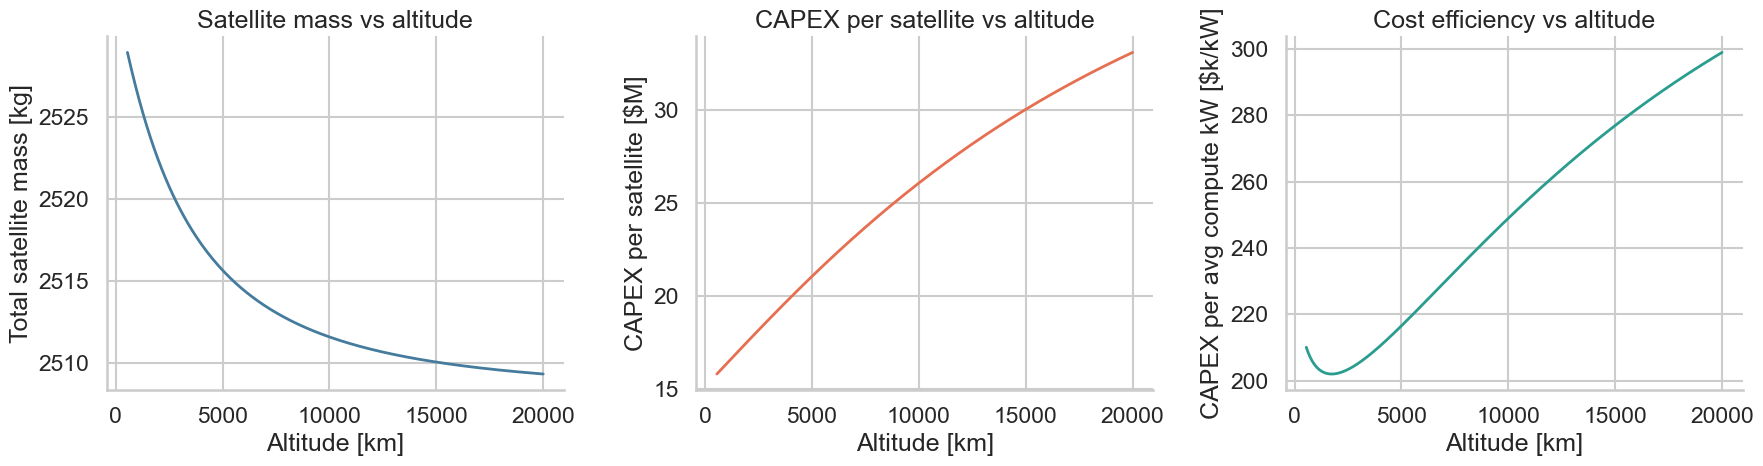

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(df["alt_km"], df["m_total_kg"], color='#457b9d', linewidth=2)
axes[0].set_xlabel("Altitude [km]")
axes[0].set_ylabel("Total satellite mass [kg]")
axes[0].set_title("Satellite mass vs altitude")
axes[0].grid(True)

axes[1].plot(df["alt_km"], df["capex_usd"]/1e6, color='#e76f51', linewidth=2)
axes[1].set_xlabel("Altitude [km]")
axes[1].set_ylabel("CAPEX per satellite [$M]")
axes[1].set_title("CAPEX per satellite vs altitude")
axes[1].grid(True)

axes[2].plot(df["alt_km"], df["capex_per_avg_compute_kw_usd_per_kw"]/1e3, color='#2a9d8f', linewidth=2)
axes[2].set_xlabel("Altitude [km]")
axes[2].set_ylabel("CAPEX per avg compute kW [$k/kW]")
axes[2].set_title("Cost efficiency vs altitude")
axes[2].grid(True)

plt.tight_layout()
plt.show()


### Implied altitude premium vs orbit altitude

The plot below shows how the launch-equivalent cost grows as the target orbit moves above the `550 km` baseline.

The most important quantity is the **incremental altitude premium in `$/kg delivered`**:

$$
\Delta c_{\text{alt}}(h) = c_{550} \, [M(h)-1]
$$

This is the extra launch-equivalent cost required to place `1 kg` at altitude $h$ instead of at the baseline orbit.

For readers who prefer a simpler heuristic, the second panel also shows the **average implied `$/kg/km`** over the full altitude increase:

$$
\bar c_{km}(h) = \frac{\Delta c_{\text{alt}}(h)}{h-h_0}
$$

That secondary quantity is useful for intuition, but the primary quantity to watch is still the total premium in `$/kg`, since that is what drives satellite CAPEX.


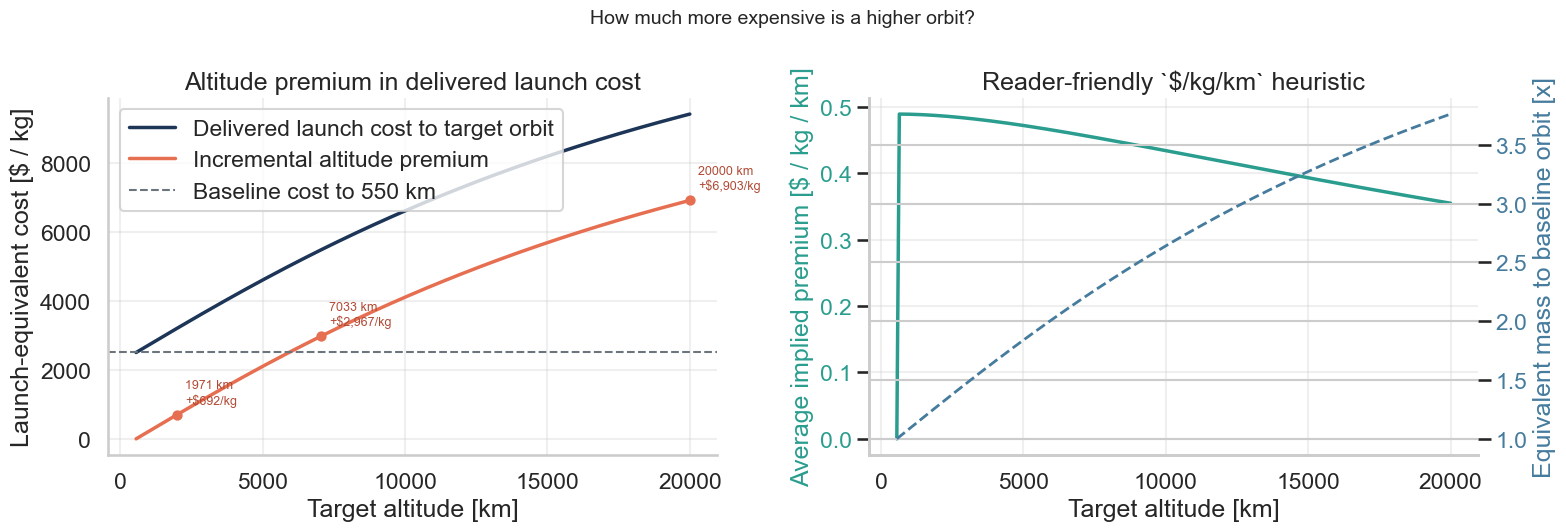

In [30]:
premium_df = df[df["alt_km"] >= ALT_BASELINE_KM].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

axes[0].plot(
    premium_df["alt_km"],
    premium_df["launch_cost_per_kg_usd"],
    color="#1d3557",
    linewidth=2.5,
    label="Delivered launch cost to target orbit",
)
axes[0].plot(
    premium_df["alt_km"],
    premium_df["altitude_premium_per_kg_usd"],
    color="#e76f51",
    linewidth=2.5,
    label="Incremental altitude premium",
)
axes[0].axhline(
    COST_TO_BASELINE_PER_KG,
    color="#6c757d",
    linestyle="--",
    linewidth=1.5,
    label=f"Baseline cost to {ALT_BASELINE_KM:.0f} km",
)
axes[0].set_xlabel("Target altitude [km]")
axes[0].set_ylabel("Launch-equivalent cost [$ / kg]")
axes[0].set_title("Altitude premium in delivered launch cost")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper left")

for alt_label in [2_000, 7_000, 20_000]:
    idx = (premium_df["alt_km"] - alt_label).abs().idxmin()
    row = premium_df.loc[idx]
    axes[0].scatter(row["alt_km"], row["altitude_premium_per_kg_usd"], color="#e76f51", s=35, zorder=3)
    axes[0].annotate(
        f"{row['alt_km']:.0f} km\n+${row['altitude_premium_per_kg_usd']:,.0f}/kg",
        (row["alt_km"], row["altitude_premium_per_kg_usd"]),
        textcoords="offset points",
        xytext=(6, 8),
        fontsize=9,
        color="#b24a35",
    )

axes[1].plot(
    premium_df["alt_km"],
    premium_df["avg_altitude_premium_usd_per_kg_per_km"],
    color="#2a9d8f",
    linewidth=2.5,
)
axes[1].set_xlabel("Target altitude [km]")
axes[1].set_ylabel("Average implied premium [$ / kg / km]", color="#2a9d8f")
axes[1].tick_params(axis="y", labelcolor="#2a9d8f")
axes[1].set_title("Reader-friendly `$/kg/km` heuristic")
axes[1].grid(True, alpha=0.3)

ax2 = axes[1].twinx()
ax2.plot(
    premium_df["alt_km"],
    premium_df["launch_mass_multiplier"],
    color="#457b9d",
    linewidth=2.0,
    linestyle="--",
)
ax2.set_ylabel("Equivalent mass to baseline orbit [x]", color="#457b9d")
ax2.tick_params(axis="y", labelcolor="#457b9d")

fig.suptitle("How much more expensive is a higher orbit?", fontsize=14)
plt.tight_layout()
plt.show()


## 6) Constellation scaling (optional)

If you want a fleet with **TARGET_TOTAL_COMPUTE_MW**, we estimate satellite count and fleet cost.

This section now includes two variants:
- **single-beta fleet**: all satellites assumed to operate at one beta angle (`BETA_DEG`)
- **coverage-optimized beta mix**: satellites distributed across `CONSTELLATION_BETA_MIX`

The mix is intended as a realistic simplification for global internet LLM serving, where planes are spread for coverage and not all can remain at dawn-dusk geometry.


In [31]:
def fleet_estimate(alt_km: float, mode: str, target_compute_mw: float, beta_deg=None) -> dict:
    beta = BETA_DEG if beta_deg is None else float(beta_deg)
    b = satellite_mass_breakdown(alt_km, mode, beta_deg=beta)
    sat_avg_mw = b["avg_compute_kw"] / 1000
    n_sats = int(np.ceil(target_compute_mw / max(sat_avg_mw, 1e-9)))
    capex = satellite_capex_usd(b) * n_sats
    return {
        "alt_km": alt_km,
        "mode": mode,
        "beta_deg": beta,
        "target_compute_mw": target_compute_mw,
        "satellites_needed": n_sats,
        "fleet_capex_usd": capex,
        "fleet_mass_tonnes": n_sats * b["m_total_kg"] / 1000,
        "avg_compute_mw_delivered": n_sats * sat_avg_mw,
        "sunlight_fraction": b["sunlight_fraction"],
    }

def fleet_estimate_constellation_mix(alt_km: float, mode: str, target_compute_mw: float, beta_mix: list) -> dict:
    mix = normalize_beta_mix(beta_mix)

    per_beta_rows = []
    for beta, w in mix:
        b = satellite_mass_breakdown(alt_km, mode, beta_deg=beta)
        per_beta_rows.append({
            "beta_deg": beta,
            "weight": w,
            "sunlight_fraction": b["sunlight_fraction"],
            "avg_compute_kw": b["avg_compute_kw"],
            "m_total_kg": b["m_total_kg"],
            "sat_capex_usd": satellite_capex_usd(b),
        })

    mix_df = pd.DataFrame(per_beta_rows)
    sat_avg_mw_weighted = float(np.sum(mix_df["weight"] * mix_df["avg_compute_kw"]) / 1000.0)
    sat_mass_kg_weighted = float(np.sum(mix_df["weight"] * mix_df["m_total_kg"]))
    sat_capex_usd_weighted = float(np.sum(mix_df["weight"] * mix_df["sat_capex_usd"]))
    sunlight_fraction_weighted = float(np.sum(mix_df["weight"] * mix_df["sunlight_fraction"]))

    n_sats = int(np.ceil(target_compute_mw / max(sat_avg_mw_weighted, 1e-9)))

    return {
        "alt_km": alt_km,
        "mode": mode,
        "target_compute_mw": target_compute_mw,
        "satellites_needed": n_sats,
        "fleet_capex_usd": sat_capex_usd_weighted * n_sats,
        "fleet_mass_tonnes": sat_mass_kg_weighted * n_sats / 1000.0,
        "avg_compute_mw_delivered": sat_avg_mw_weighted * n_sats,
        "sunlight_fraction_weighted": sunlight_fraction_weighted,
        "sat_capex_weighted_usd": sat_capex_usd_weighted,
        "sat_mass_weighted_kg": sat_mass_kg_weighted,
        "beta_mix_used": mix,
    }

# Example comparison at representative altitudes.
for test_alt in [550, 1_000, 2_000, 10_000]:
    single = fleet_estimate(test_alt, "sunonly", TARGET_TOTAL_COMPUTE_MW, beta_deg=BETA_DEG)
    mixed = fleet_estimate_constellation_mix(test_alt, "sunonly", TARGET_TOTAL_COMPUTE_MW, CONSTELLATION_BETA_MIX)
    print({
        "alt_km": test_alt,
        "sunonly_single_beta_sats": single["satellites_needed"],
        "sunonly_mixed_beta_sats": mixed["satellites_needed"],
        "single_beta_fleet_capex_usd": single["fleet_capex_usd"],
        "mixed_beta_fleet_capex_usd": mixed["fleet_capex_usd"],
        "mixed_weighted_f_sun": mixed["sunlight_fraction_weighted"],
    })


{'alt_km': 550, 'sunonly_single_beta_sats': 133, 'sunonly_mixed_beta_sats': 122, 'single_beta_fleet_capex_usd': 2105276644.7309034, 'mixed_beta_fleet_capex_usd': 1931407062.0875437, 'mixed_weighted_f_sun': 0.6874554285518353}
{'alt_km': 1000, 'sunonly_single_beta_sats': 125, 'sunonly_mixed_beta_sats': 110, 'single_beta_fleet_capex_usd': 2047148155.2216346, 'mixed_beta_fleet_capex_usd': 1801860314.4801, 'mixed_weighted_f_sun': 0.7640755148775573}
{'alt_km': 2000, 'sunonly_single_beta_sats': 115, 'sunonly_mixed_beta_sats': 103, 'single_beta_fleet_capex_usd': 2022657458.5377705, 'mixed_beta_fleet_capex_usd': 1811928532.6866102, 'mixed_weighted_f_sun': 0.8136616872262576}
{'alt_km': 10000, 'sunonly_single_beta_sats': 96, 'sunonly_mixed_beta_sats': 87, 'single_beta_fleet_capex_usd': 2503264591.341241, 'mixed_beta_fleet_capex_usd': 2268974673.905335, 'mixed_weighted_f_sun': 0.9618292059423521}


## 7) Final scenario: a 200 MW orbital LLM datacenter

The preceding sections explored three coupled design drivers — thermal rejection, sunlight availability, and mass/cost scaling — across a wide range of assumptions. Here we synthesize those findings into a single, concrete reference scenario sized to a **200 MW** orbital datacenter.

### Separating GPU cost from space premium

An important framing point: **the GPU hardware itself costs the same whether it sits in a terrestrial rack or orbits at 7,000 km.** Our model includes a coupled compute cost of \$16,000 per nameplate kW (`COMPUTE_COST_PER_KW`), which covers the GPU modules, interconnects, and associated electronics. This cost is identical for a ground datacenter.

What makes a space datacenter expensive is everything *else* — the **space premium**: radiators to reject heat, solar arrays to generate power, the satellite bus/structure, and most critically the launch cost to put all that mass into orbit. These are costs that a terrestrial datacenter simply does not pay (it uses grid power, air/water cooling, and a building on the ground instead).

So the right comparison is not "total space fleet CAPEX vs. terrestrial datacenter CAPEX." It is:

> **How much additional cost does putting compute in space add on top of the GPU hardware cost that you'd pay either way?**

Below, we compute both the total CAPEX and the **space premium** (total CAPEX minus GPU hardware cost) to make this comparison transparent.

### Design choices and rationale

**GPU operating temperature: 90 °C.** The thermal sensitivity analysis (Section 2) showed that radiator area — and therefore mass and cost — drops steeply as GPU junction temperature rises from 70 °C to around 90 °C. Above 90 °C, the marginal savings per additional degree flatten out. Running at 90 °C balances thermal efficiency against the engineering risk of pushing chip temperatures higher.

**Operating mode: sunlight-only inference (no batteries).** As established in Section 1, batteries for 24/7 operation nearly double satellite mass. Sunlight-only is the clear choice for a constellation where fleet-level diversity handles eclipse gaps.

**Constellation geometry: coverage-optimized beta mix.** As discussed in Section 4, a global inference service requires orbital planes at many orientations, not just the ideal dawn-dusk geometry. Our constellation beta mix (30% at $\beta=0°$, 45% at $\beta=30°$, 20% at $\beta=60°$, 5% at $\beta=90°$) represents a realistic spread for internet-facing coverage.

**Altitude: 7,000 km (MEO).** Altitude involves a three-way tradeoff:
- **Sunlight**: higher altitudes yield shorter eclipses and higher sunlight fractions. At 7,000 km with our beta mix, the weighted sunlight fraction is much better than LEO.
- **Latency**: one-way nadir propagation delay at 7,000 km is about 23 ms. For LLM inference, where token generation latency already dominates at 50-200+ ms, this is acceptable.
- **Launch cost**: our simple Hohmann-transfer cost model shows moderate cost growth from the baseline orbit to 7,000 km.
- **Thermal environment**: at 7,000 km, Earth's thermal backload on radiators is negligible because Earth subtends a much smaller solid angle.

**Target scale: 200 MW of delivered average compute.** This is meant to represent a large, concrete orbital datacenter case rather than an abstract fleet-size sweep. The final cells below now show:

1. The sizing math from `200 MW` target compute to satellites required.
2. The weighted-average per-satellite mass and cost to orbit.
3. The per-satellite masses of compute hardware, radiators, solar arrays, and bus/structure.
4. The final constellation split across beta bins so the fleet composition is explicit.

### Computation

The following cells price this specific `200 MW` scenario and break the result into **GPU hardware** (same on Earth) and the **space premium** (radiators, solar arrays, bus, and launch). They also show the intermediate calculations so the final constellation numbers are easy to audit.

In [32]:
from IPython.display import display

# ---- Reference scenario parameters ----
SCENARIO_ALT_KM = 7_000.0              # MEO altitude
SCENARIO_GPU_C = T_GPU_C               # tie the scenario to the notebook's main GPU temperature knob
SCENARIO_MODE = "sunonly"             # sunlight-only (no batteries)
SCENARIO_TARGET_MW = 200.0             # final datacenter size


def allocate_satellites_by_mix(total_sats: int, mix: list) -> np.ndarray:
    """Allocate an integer satellite count across mix weights using largest remainder."""
    weights = np.array([w for _, w in mix], dtype=float)
    raw_counts = total_sats * weights
    counts = np.floor(raw_counts).astype(int)
    remainder = int(total_sats - counts.sum())
    order = np.argsort(-(raw_counts - counts))
    counts[order[:remainder]] += 1
    return counts


# ---- Scenario setup ----
GPU_COST_PER_SAT = COMPUTE_COST_PER_KW * P_COMPUTE_KW
scenario_mix = normalize_beta_mix(CONSTELLATION_BETA_MIX)
scenario_sun = constellation_sunlight_metrics(SCENARIO_ALT_KM, scenario_mix)
scenario_fleet = fleet_estimate_constellation_mix(
    alt_km=SCENARIO_ALT_KM,
    mode=SCENARIO_MODE,
    target_compute_mw=SCENARIO_TARGET_MW,
    beta_mix=CONSTELLATION_BETA_MIX,
)

cost_per_kg = effective_cost_per_kg_to_altitude(
    SCENARIO_ALT_KM,
    ALT_BASELINE_KM,
    COST_TO_BASELINE_PER_KG,
    ISP_TRANSFER_S,
    PROPULSION_STRUCT_FRAC,
)
launch_mass_multiplier = cost_per_kg / COST_TO_BASELINE_PER_KG
satellite_counts = allocate_satellites_by_mix(scenario_fleet["satellites_needed"], scenario_mix)

# ---- Build a concrete constellation breakdown by beta bin ----
scenario_beta_rows = []
for (beta, weight), sat_count in zip(scenario_mix, satellite_counts):
    breakdown = satellite_mass_breakdown(SCENARIO_ALT_KM, SCENARIO_MODE, beta_deg=beta)
    bus_mass_kg = (
        breakdown["m_total_kg"]
        - breakdown["m_compute_kg"]
        - breakdown["m_radiator_kg"]
        - breakdown["m_array_kg"]
        - breakdown["m_battery_kg"]
    )
    array_cost_usd = breakdown["p_array_peak_w"] * ARRAY_COST_PER_W
    radiator_cost_usd = breakdown["a_radiator_m2"] * RADIATOR_COST_PER_M2
    battery_cost_usd = (
        breakdown["m_battery_kg"] * BATTERY_SPECIFIC_ENERGY_WH_PER_KG / 1000.0
    ) * BATTERY_COST_PER_KWH
    launch_cost_usd = breakdown["m_total_kg"] * cost_per_kg
    sat_capex_usd = satellite_capex_usd(breakdown)

    scenario_beta_rows.append({
        "beta_deg": beta,
        "fleet_share": weight,
        "satellites_in_bin": int(sat_count),
        "sunlight_fraction": breakdown["sunlight_fraction"],
        "avg_compute_mw_per_sat": breakdown["avg_compute_kw"] / 1000.0,
        "delivered_compute_mw_bin": int(sat_count) * breakdown["avg_compute_kw"] / 1000.0,
        "compute_mass_kg_per_sat": breakdown["m_compute_kg"],
        "radiator_area_m2_per_sat": breakdown["a_radiator_m2"],
        "radiator_mass_kg_per_sat": breakdown["m_radiator_kg"],
        "solar_array_mass_kg_per_sat": breakdown["m_array_kg"],
        "battery_mass_kg_per_sat": breakdown["m_battery_kg"],
        "bus_and_structure_kg_per_sat": bus_mass_kg,
        "total_mass_kg_per_sat": breakdown["m_total_kg"],
        "launch_cost_usd_per_sat": launch_cost_usd,
        "radiator_cost_usd_per_sat": radiator_cost_usd,
        "solar_array_cost_usd_per_sat": array_cost_usd,
        "battery_cost_usd_per_sat": battery_cost_usd,
        "total_capex_usd_per_sat": sat_capex_usd,
        "space_premium_usd_per_sat": sat_capex_usd - GPU_COST_PER_SAT,
        "fleet_mass_tonnes_bin": int(sat_count) * breakdown["m_total_kg"] / 1000.0,
        "fleet_launch_cost_usd_bin": int(sat_count) * launch_cost_usd,
        "fleet_capex_usd_bin": int(sat_count) * sat_capex_usd,
    })

scenario_beta_df = pd.DataFrame(scenario_beta_rows)
actual_weights = scenario_beta_df["satellites_in_bin"] / max(scenario_beta_df["satellites_in_bin"].sum(), 1)

weighted_avg_compute_mw_per_sat = float(
    np.sum(actual_weights * scenario_beta_df["avg_compute_mw_per_sat"])
)
weighted_satellite_mass_kg = float(
    np.sum(actual_weights * scenario_beta_df["total_mass_kg_per_sat"])
)
weighted_launch_cost_per_sat = float(
    np.sum(actual_weights * scenario_beta_df["launch_cost_usd_per_sat"])
)
weighted_satellite_capex_usd = float(
    np.sum(actual_weights * scenario_beta_df["total_capex_usd_per_sat"])
)
weighted_space_premium_usd = float(
    np.sum(actual_weights * scenario_beta_df["space_premium_usd_per_sat"])
)

n_sats = int(scenario_beta_df["satellites_in_bin"].sum())
fleet_avg_compute_mw = float(scenario_beta_df["delivered_compute_mw_bin"].sum())
fleet_total_mass_tonnes = float(scenario_beta_df["fleet_mass_tonnes_bin"].sum())
fleet_total_launch_cost_usd = float(scenario_beta_df["fleet_launch_cost_usd_bin"].sum())
fleet_total_capex_usd = float(scenario_beta_df["fleet_capex_usd_bin"].sum())
fleet_gpu_cost_usd = GPU_COST_PER_SAT * n_sats
fleet_space_premium_usd = fleet_total_capex_usd - fleet_gpu_cost_usd

calculation_trace_df = pd.DataFrame([
    {
        "Step": "Target average compute",
        "Calculation": "Given scenario size",
        "Result": f"{SCENARIO_TARGET_MW:.1f} MW",
    },
    {
        "Step": "Weighted sunlight fraction",
        "Calculation": "sum(share x sunlight fraction across beta bins)",
        "Result": f"{scenario_sun['sunlight_fraction_weighted']:.3f}",
    },
    {
        "Step": "Average compute per satellite",
        "Calculation": f"{P_COMPUTE_KW/1000:.3f} MW nameplate x {scenario_sun['sunlight_fraction_weighted']:.3f}",
        "Result": f"{weighted_avg_compute_mw_per_sat:.3f} MW/sat",
    },
    {
        "Step": "Satellites required",
        "Calculation": f"ceil({SCENARIO_TARGET_MW:.1f} / {weighted_avg_compute_mw_per_sat:.3f})",
        "Result": f"{n_sats} satellites",
    },
    {
        "Step": "Weighted satellite mass",
        "Calculation": "sum(share x per-satellite mass across beta bins)",
        "Result": f"{weighted_satellite_mass_kg/1000:.3f} t/sat",
    },
    {
        "Step": "Delivered launch cost",
        "Calculation": f"effective_cost_per_kg_to_altitude({SCENARIO_ALT_KM:.0f} km)",
        "Result": f"${cost_per_kg:,.0f}/kg",
    },
    {
        "Step": "Launch mass multiplier vs 550 km",
        "Calculation": "delivered $/kg divided by baseline 550 km $/kg",
        "Result": f"{launch_mass_multiplier:.2f}x",
    },
    {
        "Step": "Fleet delivered compute",
        "Calculation": f"{n_sats} x {weighted_avg_compute_mw_per_sat:.3f} MW/sat",
        "Result": f"{fleet_avg_compute_mw:.1f} MW",
    },
    {
        "Step": "Fleet mass",
        "Calculation": f"{n_sats} x {weighted_satellite_mass_kg/1000:.3f} t/sat",
        "Result": f"{fleet_total_mass_tonnes:,.0f} tonnes",
    },
    {
        "Step": "Fleet GPU cost",
        "Calculation": f"{n_sats} x ${GPU_COST_PER_SAT/1e6:.2f}M GPU hardware per sat",
        "Result": f"${fleet_gpu_cost_usd/1e9:.2f} B",
    },
    {
        "Step": "Fleet total CAPEX",
        "Calculation": "sum of compute hardware, radiators, solar arrays, bus, and launch",
        "Result": f"${fleet_total_capex_usd/1e9:.2f} B",
    },
    {
        "Step": "Fleet space premium",
        "Calculation": "total CAPEX minus GPU hardware cost",
        "Result": f"${fleet_space_premium_usd/1e9:.2f} B",
    },
])

space_premium_summary_df = pd.DataFrame([
    {
        "Metric": "Per-satellite GPU hardware cost",
        "Value": f"${GPU_COST_PER_SAT/1e6:.2f} M",
    },
    {
        "Metric": "Per-satellite total CAPEX",
        "Value": f"${weighted_satellite_capex_usd/1e6:.2f} M",
    },
    {
        "Metric": "Per-satellite space premium",
        "Value": f"${weighted_space_premium_usd/1e6:.2f} M",
    },
    {
        "Metric": "Fleet GPU hardware cost",
        "Value": f"${fleet_gpu_cost_usd/1e9:.2f} B",
    },
    {
        "Metric": "Fleet total CAPEX",
        "Value": f"${fleet_total_capex_usd/1e9:.2f} B",
    },
    {
        "Metric": "Fleet space premium",
        "Value": f"${fleet_space_premium_usd/1e9:.2f} B",
    },
])

per_sat_component_df = pd.DataFrame([
    {
        "Component": "Compute hardware",
        "Weighted avg mass per satellite [kg]": float(np.sum(actual_weights * scenario_beta_df["compute_mass_kg_per_sat"])),
        "Weighted avg cost per satellite [$M]": GPU_COST_PER_SAT / 1e6,
    },
    {
        "Component": "Radiators",
        "Weighted avg mass per satellite [kg]": float(np.sum(actual_weights * scenario_beta_df["radiator_mass_kg_per_sat"])),
        "Weighted avg cost per satellite [$M]": float(np.sum(actual_weights * scenario_beta_df["radiator_cost_usd_per_sat"])) / 1e6,
    },
    {
        "Component": "Solar arrays",
        "Weighted avg mass per satellite [kg]": float(np.sum(actual_weights * scenario_beta_df["solar_array_mass_kg_per_sat"])),
        "Weighted avg cost per satellite [$M]": float(np.sum(actual_weights * scenario_beta_df["solar_array_cost_usd_per_sat"])) / 1e6,
    },
    {
        "Component": "Batteries",
        "Weighted avg mass per satellite [kg]": float(np.sum(actual_weights * scenario_beta_df["battery_mass_kg_per_sat"])),
        "Weighted avg cost per satellite [$M]": float(np.sum(actual_weights * scenario_beta_df["battery_cost_usd_per_sat"])) / 1e6,
    },
    {
        "Component": "Bus and structure",
        "Weighted avg mass per satellite [kg]": float(np.sum(actual_weights * scenario_beta_df["bus_and_structure_kg_per_sat"])),
        "Weighted avg cost per satellite [$M]": BUS_COST_FIXED / 1e6,
    },
    {
        "Component": "Launch to orbit",
        "Weighted avg mass per satellite [kg]": np.nan,
        "Weighted avg cost per satellite [$M]": weighted_launch_cost_per_sat / 1e6,
    },
    {
        "Component": "Total satellite",
        "Weighted avg mass per satellite [kg]": weighted_satellite_mass_kg,
        "Weighted avg cost per satellite [$M]": weighted_satellite_capex_usd / 1e6,
    },
    {
        "Component": "Space premium only",
        "Weighted avg mass per satellite [kg]": np.nan,
        "Weighted avg cost per satellite [$M]": weighted_space_premium_usd / 1e6,
    },
])

constellation_summary_df = scenario_beta_df[[
    "beta_deg",
    "fleet_share",
    "satellites_in_bin",
    "sunlight_fraction",
    "avg_compute_mw_per_sat",
    "delivered_compute_mw_bin",
    "compute_mass_kg_per_sat",
    "radiator_mass_kg_per_sat",
    "solar_array_mass_kg_per_sat",
    "bus_and_structure_kg_per_sat",
    "total_mass_kg_per_sat",
    "launch_cost_usd_per_sat",
    "fleet_mass_tonnes_bin",
]].copy()
constellation_summary_df.columns = [
    "Beta [deg]",
    "Fleet share",
    "Satellites",
    "Sunlight fraction",
    "Avg compute per sat [MW]",
    "Compute delivered by bin [MW]",
    "Compute mass per sat [kg]",
    "Radiator mass per sat [kg]",
    "Solar array mass per sat [kg]",
    "Bus/structure per sat [kg]",
    "Total mass per sat [kg]",
    "Launch cost per sat [$]",
    "Fleet mass by bin [tonnes]",
]

sensitivity_rows = []
for alt in [550, 1_000, 2_000, 5_000, 7_000, 10_000]:
    est = fleet_estimate_constellation_mix(alt, SCENARIO_MODE, SCENARIO_TARGET_MW, CONSTELLATION_BETA_MIX)
    n = est["satellites_needed"]
    gpu_cost = GPU_COST_PER_SAT * n
    total_capex = est["fleet_capex_usd"]
    space_premium = total_capex - gpu_cost
    sensitivity_rows.append({
        "Altitude [km]": alt,
        "Satellites": n,
        "GPU cost [$B]": gpu_cost / 1e9,
        "Space premium [$B]": space_premium / 1e9,
        "Total CAPEX [$B]": total_capex / 1e9,
        "Weighted sunlight fraction": est["sunlight_fraction_weighted"],
    })
sensitivity_df = pd.DataFrame(sensitivity_rows)

one_way_ms = (1_000.0 * SCENARIO_ALT_KM / C_LIGHT_M_PER_S) * 1_000.0

print("=== Final 200 MW Scenario ===")
print(f"Altitude:                     {SCENARIO_ALT_KM:.0f} km")
print(f"GPU temperature:              {SCENARIO_GPU_C:.0f} °C")
print(f"Radiator temperature:         {radiator_temp_c(SCENARIO_GPU_C, DELTA_T_TO_RADIATOR_C):.0f} °C")
print(f"Operating mode:               Sunlight-only")
print(f"Weighted sunlight fraction:   {scenario_sun['sunlight_fraction_weighted']:.3f}")
print(f"Weighted eclipse min/orbit:   {scenario_sun['eclipse_min_weighted']:.1f} min")
print(f"Launch cost to {SCENARIO_ALT_KM:.0f} km:      ${cost_per_kg:,.0f}/kg delivered")
print(f"Launch multiplier vs 550 km:  {launch_mass_multiplier:.2f}x")
print()
print(f"Satellites required:          {n_sats}")
print(f"Fleet average compute:        {fleet_avg_compute_mw:.1f} MW")
print(f"Fleet total mass:             {fleet_total_mass_tonnes:,.0f} tonnes")
print(f"Fleet launch cost:            ${fleet_total_launch_cost_usd/1e9:.2f} B")
print(f"Fleet GPU cost:               ${fleet_gpu_cost_usd/1e9:.2f} B")
print(f"Fleet total CAPEX:            ${fleet_total_capex_usd/1e9:.2f} B")
print(f"Fleet space premium:          ${fleet_space_premium_usd/1e9:.2f} B")
print(f"Space premium formula:        ${fleet_total_capex_usd/1e9:.2f} B - ${fleet_gpu_cost_usd/1e9:.2f} B = ${fleet_space_premium_usd/1e9:.2f} B")
print(f"One-way nadir latency:        {one_way_ms:.1f} ms")

print("\nCalculation trace")
display(calculation_trace_df)

print("Space premium summary")
display(space_premium_summary_df)

print("Weighted-average per-satellite mass and cost")
display(per_sat_component_df)

print("Concrete constellation breakdown by beta bin")
display(constellation_summary_df)

print("Altitude sensitivity for the same 200 MW target")
display(sensitivity_df)


=== Final 200 MW Scenario ===
Altitude:                     7000 km
GPU temperature:              90 °C
Radiator temperature:         60 °C
Operating mode:               Sunlight-only
Weighted sunlight fraction:   0.953
Weighted eclipse min/orbit:   12.2 min
Launch cost to 7000 km:      $5,453/kg delivered
Launch multiplier vs 550 km:  2.18x

Satellites required:          1750
Fleet average compute:        200.0 MW
Fleet total mass:             4,400 tonnes
Fleet launch cost:            $23.99 B
Fleet GPU cost:               $3.36 B
Fleet space premium:          $37.25 B
Fleet total CAPEX:            $40.61 B
One-way nadir latency:        23.3 ms

Calculation trace


,Step,Calculation,Result
0,Target average compute,Given scenario size,200.0 MW
1,Weighted sunlight fraction,sum(share x sunlight fraction across beta bins),0.953
2,Average compute per satellite,0.120 MW nameplate x 0.953,0.114 MW/sat
3,Satellites required,ceil(200.0 / 0.114),1750 satellites
4,Weighted satellite mass,sum(share x per-satellite mass across beta bins),2.514 t/sat
5,Delivered launch cost,effective_cost_per_kg_to_altitude(7000 km),"$5,453/kg"
6,Launch mass multiplier vs 550 km,delivered $/kg divided by baseline 550 km $/kg,2.18x
7,Fleet delivered compute,1750 x 0.114 MW/sat,200.0 MW
8,Fleet mass,1750 x 2.514 t/sat,"4,400 tonnes"


Weighted-average per-satellite mass and cost


,Component,Weighted avg mass per satellite [kg],Weighted avg cost per satellite [$M]
0,Compute hardware,750.000000,1.920000
1,Radiators,475.711552,0.475712
2,Solar arrays,660.000000,6.600000
3,Batteries,0.000000,0.000000
4,Bus and structure,628.570517,0.500000
5,Launch to orbit,NaN,13.710982
6,Total satellite,2514.282070,23.206693
7,Space premium only,NaN,21.286693


Concrete constellation breakdown by beta bin


,Beta [deg],Fleet share,Satellites,Sunlight fraction,Avg compute per sat [MW],Compute delivered by bin [MW],Compute mass per sat [kg],Radiator mass per sat [kg],Solar array mass per sat [kg],Bus/structure per sat [kg],Total mass per sat [kg],Launch cost per sat [$],Fleet mass by bin [tonnes]
0,0.0,0.30,525,0.841913,0.10103,53.040509,750.0,475.109404,660.0,628.369801,2513.479205,1.370660e+07,1319.576583
1,30.0,0.45,788,1.000000,0.12000,94.560000,750.0,475.969616,660.0,628.656539,2514.626154,1.371286e+07,1981.525410
2,60.0,0.20,350,1.000000,0.12000,42.000000,750.0,475.969616,660.0,628.656539,2514.626154,1.371286e+07,880.119154
3,90.0,0.05,87,1.000000,0.12000,10.440000,750.0,475.969616,660.0,628.656539,2514.626154,1.371286e+07,218.772475


Altitude sensitivity for the same 200 MW target


,Altitude [km],Satellites,GPU cost [$B],Space premium [$B],Total CAPEX [$B],Weighted sunlight fraction
0,550,2425,4.65600,33.734673,38.390673,0.687455
1,1000,2182,4.18944,31.552916,35.742356,0.764076
2,2000,2049,3.93408,32.110984,36.045064,0.813662
3,5000,1851,3.55392,35.452218,39.006138,0.900773
4,7000,1750,3.36000,37.251713,40.611713,0.952574
5,10000,1733,3.32736,41.869572,45.196932,0.961829


### Interpreting the result

#### The space premium is the real comparison

A terrestrial datacenter also pays for GPU hardware, so that part is a wash. The meaningful comparison is the **space premium**: the additional cost of radiators, solar arrays, satellite bus, and launch that a terrestrial datacenter replaces with grid power, HVAC, and a building.

The new tables above make that premium more concrete in two ways:

- The **calculation trace** shows exactly how the `200 MW` target turns into a required satellite count.
- The **weighted per-satellite table** shows the mass of compute hardware, radiators, solar arrays, and bus/structure per satellite, along with the launch cost to orbit one satellite.
- The **beta-bin table** shows what the final constellation actually looks like across orbital geometries.

#### What dominates the design

The per-satellite breakdown makes clear that launch and solar arrays dominate the space premium, while radiator hardware is important mainly because it adds mass that must also be launched. This means:

- **Cheaper launch** is still the single highest-leverage improvement.
- **Higher specific-power solar arrays** reduce array mass directly and also reduce the launch bill for that mass.
- **Higher GPU operating temperatures** help by shrinking radiator area, which cascades into lower radiator mass and lower launch cost.

#### Altitude sensitivity

The sensitivity table now shows the same comparison for the `200 MW` target:

- **LEO (550 km)**: lowest launch cost per kg, but worst sunlight fraction. More satellites are required, which increases fleet complexity.
- **MEO (5,000-7,000 km)**: markedly better sunlight fractions, fewer satellites needed, and negligible Earth thermal backload on radiators.
- **7,000 km** remains a practical balance between sunlight, latency, and launch cost for this first-pass model.

#### Bottom line

For this first-order model, a **200 MW orbital LLM datacenter** still carries a multi-billion-dollar space premium above the GPU hardware itself. The notebook now makes that conclusion easier to audit by exposing the satellite count, per-satellite masses, per-satellite launch cost, and the final constellation mix directly instead of leaving those values implicit.

## 8) What this model is useful for (and where it is weak)

### What it does well

This notebook provides a **transparent, first-order feasibility model** for space-based GPU datacenters. It is useful for:

- **Making the thermal problem concrete**: showing why heat rejection, not power generation, is the dominant sizing driver for space compute, and how GPU operating temperature directly controls radiator area and satellite mass.
- **Connecting orbit geometry to operations**: explaining how beta angle and altitude determine sunlight availability, and why a global-coverage constellation cannot simply live in the most favorable orbits.
- **Turning assumptions into cost estimates**: propagating a small set of editable parameters (GPU power, solar array specific power, launch cost per kg, and similar knobs) into satellite-level and fleet-level CAPEX, so readers can test what-if scenarios.
- **Providing a concrete reference scenario**: the Section 7 estimate now sizes a `200 MW` datacenter and shows the intermediate math, per-satellite masses, launch cost, and final constellation composition explicitly.

### Where it falls short

This model is **not sufficient for investment or engineering decisions**. Key limitations include:

- **Thermal modeling**: we use a single-node radiator model with a simplified environmental backload. Real designs require attitude-resolved, transient thermal analysis with self-viewing, multi-layer insulation, and heat pipe networks.
- **Radiation environment**: MEO altitudes (especially near the Van Allen belts at ~2,000-7,000 km) impose significant radiation shielding requirements. This is not modeled, but would add mass and cost.
- **Lifetime and reliability**: satellite component degradation, solar cell efficiency loss, and orbital debris risk are not included.
- **Launch integration**: the `$/kg` model is a smooth function. Real launch costs depend on fairing volume, co-manifesting constraints, and market dynamics.
- **Networking and service architecture**: we do not model inter-satellite links, ground station coverage, or the economics of latency-sensitive LLM serving.
- **Regulatory and spectrum**: orbital debris mitigation, frequency coordination, and export control constraints are outside scope.

### Bottom line

This notebook is best used as a **transparent conversation starter and sensitivity tool**, not as a final investment model. The updated Section 7 shows that a space-based `200 MW` LLM datacenter is still not cost-competitive with terrestrial alternatives today, but it now makes much clearer which masses and costs dominate the result and which assumptions would need to change to move the conclusion.